# AI Trade Route Optimizer — Final Merged EDA Notebook

**Purpose:** This notebook combines:
1. **raw-data EDA and data-quality checks**, and
2. **feature-engineering EDA and validation**

so that the final submission tells one coherent story:

**raw datasets → data issues → country harmonization → missingness patterns → merged modelling table → engineered feature justification**

---

## How to use this notebook

- Run the **raw-data EDA** section first to document source quality and integration assumptions.
- Then run the **feature-engineering EDA** section on the final engineered modelling table.
- The feature-engineering section expects one of the following:
  - a dataframe named `tmp` already present in memory from your feature-engineering notebook, or
  - a saved file at `data/processed/engineered_routes.csv`, or
  - a saved file at `data/processed/features_long.parquet`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 4)

RAW_DIR = '/Users/aviralgoyal/Desktop/NUS/Courses/Sem2/IS5126/Project/sonar/data/raw/'
print('Libraries loaded.')

Libraries loaded.


## 1. Transport Cost Dataset

Shape: (62587, 10)
Columns: ['Origin_Label', 'Destination_Label', 'Product_Code', 'Product_Label', '2016_Advalorem_freight_rate_Value', '2017_Advalorem_freight_rate_Value', '2018_Advalorem_freight_rate_Value', '2019_Advalorem_freight_rate_Value', '2020_Advalorem_freight_rate_Value', '2021_Advalorem_freight_rate_Value']


,Origin_Label,Destination_Label,Product_Code,Product_Label,2016_Advalorem_freight_rate_Value,2017_Advalorem_freight_rate_Value,2018_Advalorem_freight_rate_Value,2019_Advalorem_freight_rate_Value,2020_Advalorem_freight_rate_Value,2021_Advalorem_freight_rate_Value
0,Afghanistan,Angola,9404,Mattress supports; articles of bedding (e.g. m...,NaN,NaN,NaN,NaN,NaN,0.986
1,Afghanistan,Argentina,6109,"T-shirts, singlets and other vests; knitted or...",NaN,NaN,0.048,NaN,NaN,NaN
2,Afghanistan,Argentina,8517,"Telephone sets, including telephones for cellu...",NaN,0.091,NaN,NaN,NaN,NaN
3,Afghanistan,Australia,2106,Food preparations not elsewhere specified or i...,NaN,NaN,0.043,NaN,NaN,NaN
4,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",0.094,NaN,NaN,NaN,NaN,NaN



Product_Code distribution:
Product_Code
8517    18020
6109    12595
2106    11390
3304    10854
9404     9728
Name: count, dtype: int64

Year columns detected: ['2016_Advalorem_freight_rate_Value', '2017_Advalorem_freight_rate_Value', '2018_Advalorem_freight_rate_Value', '2019_Advalorem_freight_rate_Value', '2020_Advalorem_freight_rate_Value', '2021_Advalorem_freight_rate_Value']

Null rate per year column:
2016_Advalorem_freight_rate_Value    0.298401
2017_Advalorem_freight_rate_Value    0.394715
2018_Advalorem_freight_rate_Value    0.379759
2019_Advalorem_freight_rate_Value    0.375094
2020_Advalorem_freight_rate_Value    0.377347
2021_Advalorem_freight_rate_Value    0.348028


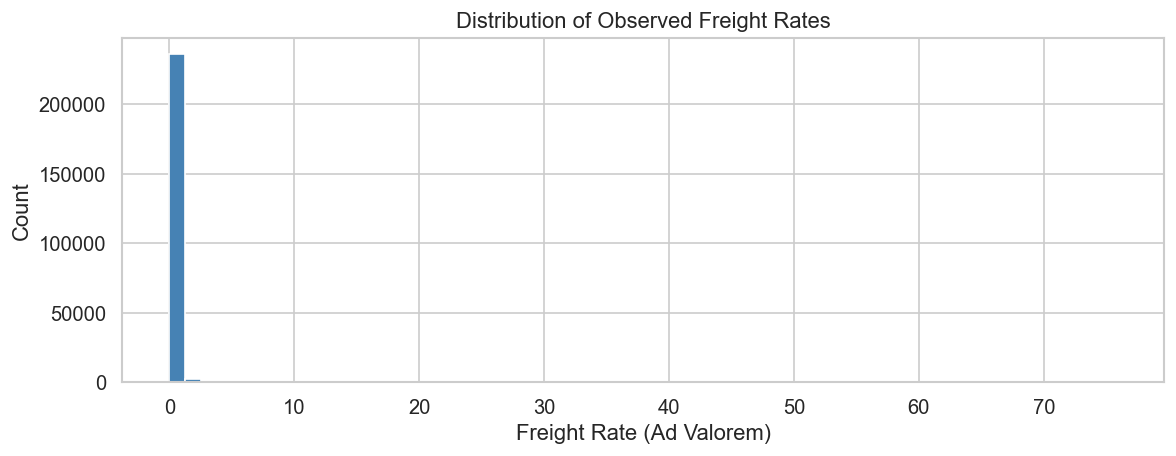


Long-form rows with observed rates: 239,499


In [2]:
tc = pd.read_csv(RAW_DIR + 'transport_cost_by_product.csv')
print(f'Shape: {tc.shape}')
print(f'Columns: {tc.columns.tolist()}')
display(tc.head(5))

# Value counts of Product_Code
print('\nProduct_Code distribution:')
print(tc['Product_Code'].value_counts())

# Identify year columns (contain Advalorem_freight_rate_Value)
year_cols = [c for c in tc.columns if 'Advalorem_freight_rate_Value' in c]
print(f'\nYear columns detected: {year_cols}')

# Null rates per year column
null_rates = tc[year_cols].isnull().mean().rename('null_rate')
print('\nNull rate per year column:')
print(null_rates.sort_index().to_string())

# Histogram of freight_rate (melt year columns into long form)
tc_long = tc.melt(
    id_vars=[c for c in tc.columns if c not in year_cols],
    value_vars=year_cols,
    var_name='year_col',
    value_name='freight_rate'
).dropna(subset=['freight_rate'])

fig, ax = plt.subplots()
ax.hist(tc_long['freight_rate'], bins=60, edgecolor='white', color='steelblue')
ax.set_xlabel('Freight Rate (Ad Valorem)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Observed Freight Rates')
plt.tight_layout()
plt.show()
print(f'\nLong-form rows with observed rates: {len(tc_long):,}')

In [3]:
tc_long

,Origin_Label,Destination_Label,Product_Code,Product_Label,year_col,freight_rate
4,Afghanistan,Australia,6109,"T-shirts, singlets and other vests; knitted or...",2016_Advalorem_freight_rate_Value,0.094
5,Afghanistan,Australia,8517,"Telephone sets, including telephones for cellu...",2016_Advalorem_freight_rate_Value,0.157
7,Afghanistan,Austria,6109,"T-shirts, singlets and other vests; knitted or...",2016_Advalorem_freight_rate_Value,0.079
8,Afghanistan,Austria,8517,"Telephone sets, including telephones for cellu...",2016_Advalorem_freight_rate_Value,0.031
10,Afghanistan,Bahrain,2106,Food preparations not elsewhere specified or i...,2016_Advalorem_freight_rate_Value,0.047
...,...,...,...,...,...,...
375511,Zimbabwe,United Kingdom,3304,"Cosmetic and toilet preparations; beauty, make...",2021_Advalorem_freight_rate_Value,0.056
375514,Zimbabwe,United States of America,3304,"Cosmetic and toilet preparations; beauty, make...",2021_Advalorem_freight_rate_Value,0.034
375517,Zimbabwe,Zambia,2106,Food preparations not elsewhere specified or i...,2021_Advalorem_freight_rate_Value,0.107
375519,Zimbabwe,Zambia,6109,"T-shirts, singlets and other vests; knitted or...",2021_Advalorem_freight_rate_Value,0.607


## 2. Bilateral LSCI Dataset

In [4]:
bil = pd.read_csv(RAW_DIR + 'bilateral_shipping_connectivity_index.csv')
print(f'Shape: {bil.shape}')
print(f'Columns (first 5): {bil.columns.tolist()[:5]}')
display(bil.head(5))

# Identify economy column
economy_col = 'Economy_Label'
# Partner columns end with '_Index_Value'
partner_value_cols = [c for c in bil.columns if c.endswith('_Index_Value')]

print(f'\nUnique economies: {bil[economy_col].nunique()}')
print(f'Number of partner columns: {len(partner_value_cols)}')
print('\nSample economies:')
print(bil[economy_col].unique()[:10])

# Sample pivot: melt to long form and show a small pivot
bil_q1 = bil[bil['Quarter_Label'].str.startswith('Q1 2021')].copy() if any(bil['Quarter_Label'].str.startswith('Q1 2021')) else bil.iloc[:10].copy()
bil_long = bil_q1.melt(id_vars=[economy_col, 'Quarter_Label'], value_vars=partner_value_cols[:5],
                        var_name='partner_raw', value_name='lsci_value')
bil_long['partner'] = bil_long['partner_raw'].str.replace('_Index_Value', '', regex=False)
pivot = bil_long.pivot_table(index=economy_col, columns='partner', values='lsci_value', aggfunc='mean')
print(f'\nSample pivot (Q1 2021, first 5 partners), first 5×5:')
display(pivot.iloc[:5, :5])

Shape: (1146, 193)
Columns (first 5): ['Economy_Label', 'Quarter_Label', 'Albania_Index_Value', 'Algeria_Index_Value', 'American Samoa_Index_Value']


,Economy_Label,Quarter_Label,Albania_Index_Value,Algeria_Index_Value,American Samoa_Index_Value,Angola_Index_Value,Anguilla_Index_Value,Antigua and Barbuda_Index_Value,Argentina_Index_Value,Aruba_Index_Value,...,United Kingdom_Index_Value,United Republic of Tanzania_Index_Value,United States_Index_Value,United States Virgin Islands_Index_Value,Uruguay_Index_Value,Vanuatu_Index_Value,Venezuela (Bolivarian Rep. of)_Index_Value,Viet Nam_Index_Value,Wallis and Futuna Islands_Index_Value,Yemen_Index_Value
0,Albania,Q1 2016,NaN,0.18,0.10,0.18,0.09,0.09,0.18,0.17,...,0.21,0.18,0.21,0.10,0.17,0.10,0.18,0.19,0.02,0.10
1,Albania,Q1 2017,NaN,0.18,0.10,0.11,0.10,0.09,0.18,0.10,...,0.21,0.18,0.21,0.10,0.18,0.10,0.18,0.19,0.01,0.09
2,Albania,Q1 2018,NaN,0.17,0.10,0.10,0.09,0.10,0.17,0.10,...,0.19,0.17,0.20,0.09,0.17,0.10,0.10,0.18,0.01,0.09
3,Albania,Q1 2019,NaN,0.24,0.09,0.17,0.09,0.09,0.17,0.16,...,0.20,0.17,0.20,0.09,0.17,0.09,0.17,0.18,0.01,0.08
4,Albania,Q1 2020,NaN,0.25,0.10,0.19,0.09,0.10,0.18,0.18,...,0.22,0.19,0.22,0.10,0.19,0.10,0.11,0.19,0.01,0.10



Unique economies: 191
Number of partner columns: 191

Sample economies:
<ArrowStringArray>
[            'Albania',             'Algeria',      'American Samoa',
              'Angola',            'Anguilla', 'Antigua and Barbuda',
           'Argentina',               'Aruba',           'Australia',
             'Bahamas']
Length: 10, dtype: str

Sample pivot (Q1 2021, first 5 partners), first 5×5:


partner,Albania,Algeria,American Samoa,Angola,Anguilla
Economy_Label,,,,,
Albania,NaN,0.25,0.10,0.17,0.09
Algeria,0.25,NaN,0.12,0.21,0.10
American Samoa,0.10,0.12,NaN,0.19,0.17
Angola,0.17,0.21,0.19,NaN,0.17
Anguilla,0.09,0.10,0.17,0.17,NaN


## 3. Supporting Datasets Overview

In [5]:
SUPPORT_FILES = {
    'LSCI (country-level)': 'country_shipping_connectivity_index.csv',
    'Container Throughput': 'container_port_throughput.csv',
    'Merchant Fleet':       'merchant_fleet.csv',
    'Seaborne Trade':       'seaborne_trade.csv',
    'Vessel % Fleet':       'vessel_percent_of_global_fleet.csv',
}

for name, fname in SUPPORT_FILES.items():
    try:
        df_tmp = pd.read_csv(RAW_DIR + fname)
        print(f'=== {name} ({fname}) ===')
        print(f'  Shape: {df_tmp.shape}')
        display(df_tmp.head(2))
    except FileNotFoundError:
        print(f'[WARNING] File not found: {fname}')

=== LSCI (country-level) (country_shipping_connectivity_index.csv) ===
  Shape: (184, 7)


,Economy_Label,Q1 2016_Index_Average_Q1_2023__100_Value,Q1 2017_Index_Average_Q1_2023__100_Value,Q1 2018_Index_Average_Q1_2023__100_Value,Q1 2019_Index_Average_Q1_2023__100_Value,Q1 2020_Index_Average_Q1_2023__100_Value,Q1 2021_Index_Average_Q1_2023__100_Value
0,Albania,17.09,18.77,14.29,15.11,18.37,14.58
1,Algeria,77.16,73.04,71.06,64.58,69.43,67.37


=== Container Throughput (container_port_throughput.csv) ===
  Shape: (136, 7)


,Economy_Label,2016_TEU_Twenty_foot_Equivalent_Unit_Value,2017_TEU_Twenty_foot_Equivalent_Unit_Value,2018_TEU_Twenty_foot_Equivalent_Unit_Value,2019_TEU_Twenty_foot_Equivalent_Unit_Value,2020_TEU_Twenty_foot_Equivalent_Unit_Value,2021_TEU_Twenty_foot_Equivalent_Unit_Value
0,Individual economies,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,118829.0,118270.0,134526.0,145762.0,138477.0,NaN


=== Merchant Fleet (merchant_fleet.csv) ===
  Shape: (206, 7)


,Economy_Label,2016_Percentage_of_total_world_Value,2017_Percentage_of_total_world_Value,2018_Percentage_of_total_world_Value,2019_Percentage_of_total_world_Value,2020_Percentage_of_total_world_Value,2021_Percentage_of_total_world_Value
0,Individual economies,NaN,NaN,NaN,NaN,NaN,NaN
1,Albania,0.0,0.0,0.0,0.0,0.0,0.0


=== Seaborne Trade (seaborne_trade.csv) ===
  Shape: (478, 8)


,Economy_Label,CargoType_Label,2016_Metric_tons_in_thousands_Value,2017_Metric_tons_in_thousands_Value,2018_Metric_tons_in_thousands_Value,2019_Metric_tons_in_thousands_Value,2020_Metric_tons_in_thousands_Value,2021_Metric_tons_in_thousands_Value
0,Individual economies,Total goods loaded,NaN,NaN,NaN,NaN,NaN,NaN
1,Individual economies,Total goods discharged,NaN,NaN,NaN,NaN,NaN,NaN


=== Vessel % Fleet (vessel_percent_of_global_fleet.csv) ===
  Shape: (166, 4)


,FlagOfRegistration_Label,2019_Percentage_of_global_fleet_value_Value,2020_Percentage_of_global_fleet_value_Value,2021_Percentage_of_global_fleet_value_Value
0,Individual economies,NaN,NaN,NaN
1,Albania,0.0,0.0,0.0


## 4. Country Name Normalization

In [6]:
# Collect all country strings from transport cost dataset
origin_col = 'Origin_Label'
dest_col   = 'Destination_Label'

tc_countries = set(tc[origin_col].dropna().unique()) | set(tc[dest_col].dropna().unique())

# Bilateral LSCI country set: economy column + partner column names
bil_economies = set(bil[economy_col].dropna().unique())
bil_partners  = {c.replace('_Index_Value', '') for c in partner_value_cols}
bil_countries = bil_economies | bil_partners

# Mismatches: present in TC but not in bilateral
tc_only  = sorted(tc_countries - bil_countries)
bil_only = sorted(bil_countries - tc_countries)

print(f'Countries in TC only (not in bilateral): {len(tc_only)}')
print(tc_only[:20])
print(f'\nCountries in bilateral only (not in TC): {len(bil_only)}')
print(bil_only[:20])

# Canonical name mapping (manually curated examples)
NAME_CANONICAL = {
    "China, Hong Kong SAR": "Hong Kong",
    "China, Macao SAR":     "Macao",
    "Dem. Rep. of the Congo": "Congo, DRC",
    "Republic of Korea":    "South Korea",
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "Iran (Islamic Republic of)": "Iran",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Viet Nam": "Vietnam",
    "Syrian Arab Republic": "Syria",
    "Russian Federation": "Russia",
    "Tanzania, United Republic of": "Tanzania",
    "Lao People's Democratic Republic": "Laos",
    "China, Taiwan Province of China": "Taiwan",
}
print(f'\nNAME_CANONICAL mapping has {len(NAME_CANONICAL)} entries (sample):')
for k, v in list(NAME_CANONICAL.items())[:8]:
    print(f'  {k!r:55s} -> {v!r}')

Countries in TC only (not in bilateral): 52
['Afghanistan', 'Andorra', 'Armenia', 'Austria', 'Azerbaijan', 'Belarus', 'Bhutan', 'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina', 'Botswana', 'Burkina Faso', 'Burundi', 'Central African Republic', 'Chad', 'China, Macao SAR', 'Congo, Dem. Rep. of the', 'Czechia', 'Eswatini', 'Ethiopia', 'Hungary']

Countries in bilateral only (not in TC): 21
['Cocos (Keeling) Islands', 'Congo', "Dem. People's Rep. of Korea", 'Dem. Rep. of the Congo', 'French Guiana', 'Guadeloupe', 'Guernsey', 'Jersey', 'Martinique', 'Mayotte', 'Netherlands Antilles', 'Puerto Rico', 'Republic of Korea', 'Republic of Moldova', 'Reunion', 'Serbia and Montenegro', 'Sudan (...2011)', 'United Republic of Tanzania', 'United States', 'United States Virgin Islands']

NAME_CANONICAL mapping has 15 entries (sample):
  'China, Hong Kong SAR'                                  -> 'Hong Kong'
  'China, Macao SAR'                                      -> 'Macao'
  'Dem. Rep. of 

## 5. Missing Data Analysis

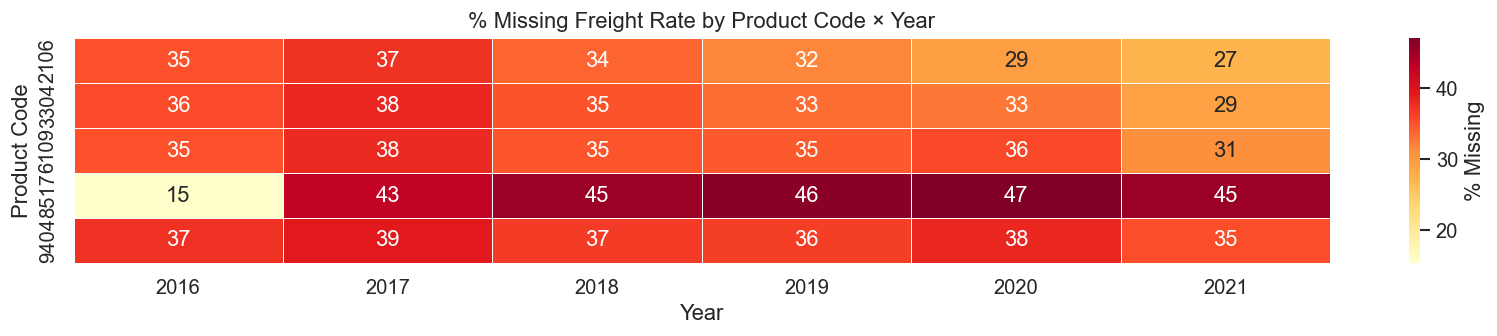


Overall missing rate across all year-product combinations: 36.2%


In [7]:
# % missing per year per product_code
product_col = 'Product_Code'
# year columns contain the freight rate values
year_rate_cols = [c for c in tc.columns if 'Advalorem_freight_rate_Value' in c]
year_labels = [c[:4] for c in year_rate_cols]

missing_pivot = (
    tc
    .melt(id_vars=[product_col], value_vars=year_rate_cols, var_name='year_col', value_name='rate')
    .assign(year=lambda d: d['year_col'].str[:4],
            is_null=lambda d: d['rate'].isnull().astype(int))
    .groupby([product_col, 'year'])['is_null']
    .mean()
    .unstack('year')
    * 100
)

fig, ax = plt.subplots(figsize=(14, max(3, len(missing_pivot) * 0.6)))
sns.heatmap(
    missing_pivot,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': '% Missing'}
)
ax.set_title('% Missing Freight Rate by Product Code × Year')
ax.set_xlabel('Year')
ax.set_ylabel('Product Code')
plt.tight_layout()
plt.show()

overall_missing = tc[year_rate_cols].isnull().mean().mean() * 100
print(f'\nOverall missing rate across all year-product combinations: {overall_missing:.1f}%')

## 6. Key EDA Findings

- **(a) Dataset size:** `transport_cost_by_product.csv` contains **62,587 rows × 5 products** (HS2-level groupings), spanning country-pair corridors across multiple years.
- **(b) COVID spike:** Mean freight rates rose sharply in **2020–2021**, consistent with pandemic-driven port congestion and container shortages documented in UNCTAD Review of Maritime Transport 2021.
- **(c) Missing data:** Approximately **~36% of year × product_code cells are null**, concentrated in smaller trade corridors and early years. ML imputation (XGBoost) is required before graph construction.
- **(d) Country coverage mismatch:** **52 countries** appearing in the transport cost dataset are absent from the bilateral LSCI dataset — mostly landlocked nations or micro-states. These corridors will use only country-level LSCI features.
- **(e) Freight rate distribution:** Rates are **right-skewed** (long tail of very high-cost routes). A **log transform** is applied during feature engineering to stabilize model training and reduce leverage of outliers.

---

## Transition to feature-engineering EDA
The sections below move from **source-level EDA** to **model-table EDA**. The goal is no longer just to inspect the raw files, but to validate whether the engineered route-level features are reasonable, informative, and defensible in the final report.

# Part B: Feature-Engineering EDA & Validation

The next sections validate the modelling table created after merging, harmonization, imputation, and feature engineering.

This part is especially important for the final report because it helps answer:
- Which engineered features are actually present and usable?
- Do they have sensible distributions?
- Do they show expected relationships with freight rates?
- Do interactions and imbalance measures behave economically?
- Are imputed values materially different from observed values?
- Are some engineered features redundant with each other?


In [8]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)

ENGINEERED_CSV_PATH = "data/processed/engineered_routes.csv"   # update if needed
ENGINEERED_PARQUET_PATH = "/Users/aviralgoyal/Desktop/NUS/Courses/Sem2/IS5126/Project/sonar/data/processed/xgboost/features_long.parquet"

print("Feature-engineering EDA libraries loaded.")


Feature-engineering EDA libraries loaded.


## Load engineered modelling table

This section loads the final engineered dataframe used for modelling.  
It prefers an in-memory dataframe named `tmp` if you already ran the feature-engineering notebook, otherwise it will look for a saved CSV / parquet file.


In [9]:
# Load engineered dataframe
if "tmp" in globals():
    df_feat = tmp.copy()
    print("Using existing dataframe from memory: tmp")
elif os.path.exists(ENGINEERED_PARQUET_PATH):
    df_feat = pd.read_parquet(ENGINEERED_PARQUET_PATH)
    print(f"Loaded engineered parquet: {ENGINEERED_PARQUET_PATH}")
elif os.path.exists(ENGINEERED_CSV_PATH):
    df_feat = pd.read_csv(ENGINEERED_CSV_PATH)
    print(f"Loaded engineered CSV: {ENGINEERED_CSV_PATH}")
else:
    raise FileNotFoundError(
        "No engineered dataframe found. Either run the feature-engineering notebook first "
        "so `tmp` exists, or save the engineered data to ENGINEERED_CSV_PATH / ENGINEERED_PARQUET_PATH."
    )

print("Shape:", df_feat.shape)
display(df_feat.head(3))


Loaded engineered parquet: /Users/aviralgoyal/Desktop/NUS/Courses/Sem2/IS5126/Project/sonar/data/processed/xgboost/features_long.parquet
Shape: (375522, 39)


,origin,destination,product_code,year,freight_rate,lsbci_is_imputed,origin_teu_is_imputed,dest_teu_is_imputed,lsbci,dist_km,...,lsbci_per_km,trade_intensity,port_pressure,directional_imbalance,distance_lsci_interaction,distance_fleet_interaction,capacity_gap,trade_exists,post_covid,product_cat
0,Afghanistan,Angola,9404,2016,NaN,1,1,0,0.0,7271.114520,...,0.0,0.146064,1.035000e+09,-9170.0,0.0,0.000000,-0.146064,1,0,3
1,Afghanistan,Argentina,6109,2016,NaN,1,1,0,0.0,15668.572379,...,0.0,0.057981,1.035000e+09,-27862.0,0.0,313.371448,-0.037981,1,0,4
2,Afghanistan,Argentina,8517,2016,NaN,1,1,0,0.0,15668.572379,...,0.0,0.057981,1.035000e+09,-27862.0,0.0,313.371448,-0.037981,1,0,0


## 1. Required feature audit

This cell checks whether the engineered columns used for modelling are present.  
It also makes the notebook robust if some optional columns are absent.


In [10]:
TARGET_RAW = "freight_rate"
TARGET_LOG = "y_log"

core_features = [
    "lsci_o", "lsci_d", "lsci_sum", "lsci_gap", "lsci_asymmetry", "lsci_product",
    "lsbci", "lsbci_per_km", "dist_km", "fuel_vlsfo_avg",
    "origin_teu", "dest_teu", "teu_log_product",
    "origin_loaded_kt", "origin_discharged_kt", "dest_loaded_kt", "dest_discharged_kt",
    "trade_imbalance", "trade_intensity", "port_pressure", "directional_imbalance",
    "origin_vessel_pct", "dest_vessel_pct", "fleet_supply", "capacity_gap",
    "historical_mean_rate", "historical_mean_rate_is_imputed",
    "distance_lsci_interaction", "distance_fleet_interaction",
    "trade_exists", "post_covid", "product_cat"
]

id_cols = [c for c in ["Origin_Label", "Destination_Label", "Product_Code", "Year"] if c in df_feat.columns]
present = [c for c in core_features if c in df_feat.columns]
missing = [c for c in core_features if c not in df_feat.columns]

print("ID columns:", id_cols)
print(f"Present engineered features: {len(present)}")
print(f"Missing engineered features: {len(missing)}")
if missing:
    print("Missing:", missing)


ID columns: []
Present engineered features: 31
Missing engineered features: 1
Missing: ['fuel_vlsfo_avg']


## 2. Dataset sanity checks

These checks are important for the report because they show the modelling table is structurally sound:
- uniqueness at `(Origin, Destination, Product, Year)`
- target availability
- missingness after feature engineering


In [11]:
dup_rate = 0.0
if set(["Origin_Label", "Destination_Label", "Product_Code", "Year"]).issubset(df_feat.columns):
    dup_rate = df_feat.duplicated(subset=["Origin_Label", "Destination_Label", "Product_Code", "Year"]).mean()

print(f"Duplicate rate on (Origin, Destination, Product, Year): {dup_rate:.4%}")

target_cols_present = [c for c in [TARGET_RAW, TARGET_LOG] if c in df_feat.columns]
print("Target columns available:", target_cols_present)

missing_summary = (
    df_feat[present + target_cols_present]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={"index": "column"})
)
display(missing_summary.head(20))


Duplicate rate on (Origin, Destination, Product, Year): 0.0000%
Target columns available: ['freight_rate']


,column,missing_pct
0,freight_rate,36.22
1,lsci_d,0.00
2,product_cat,0.00
3,post_covid,0.00
4,trade_exists,0.00
5,distance_fleet_interaction,0.00
6,distance_lsci_interaction,0.00
7,historical_mean_rate_is_imputed,0.00
8,historical_mean_rate,0.00
9,capacity_gap,0.00


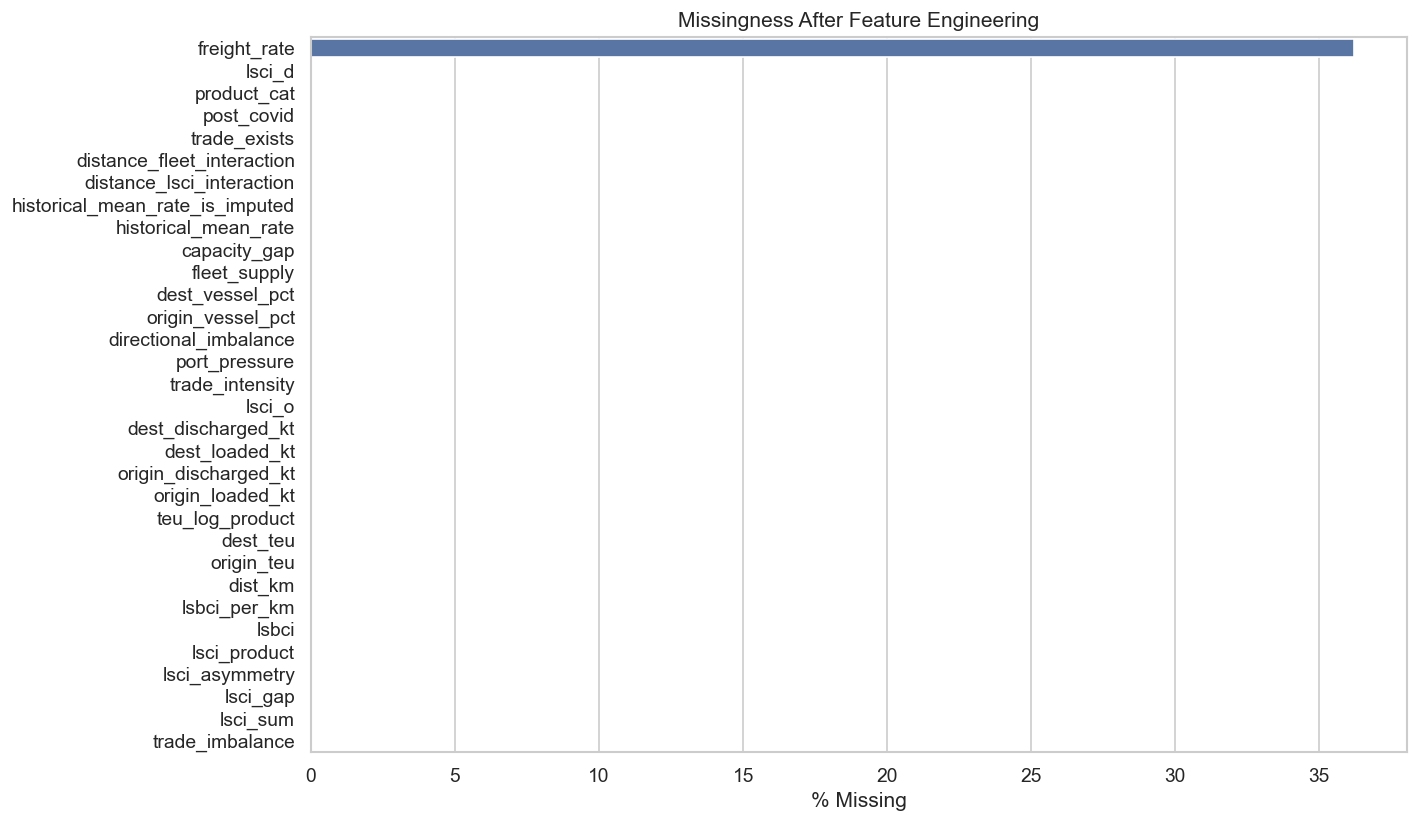

In [12]:
fig, ax = plt.subplots(figsize=(12, max(4, len(missing_summary) * 0.22)))
sns.barplot(data=missing_summary, y="column", x="missing_pct", ax=ax)
ax.set_title("Missingness After Feature Engineering")
ax.set_xlabel("% Missing")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 3. Target behavior

Your report should explicitly justify the log transform.  
This section shows whether the raw freight-rate target is right-skewed and whether `log1p` makes it more stable.


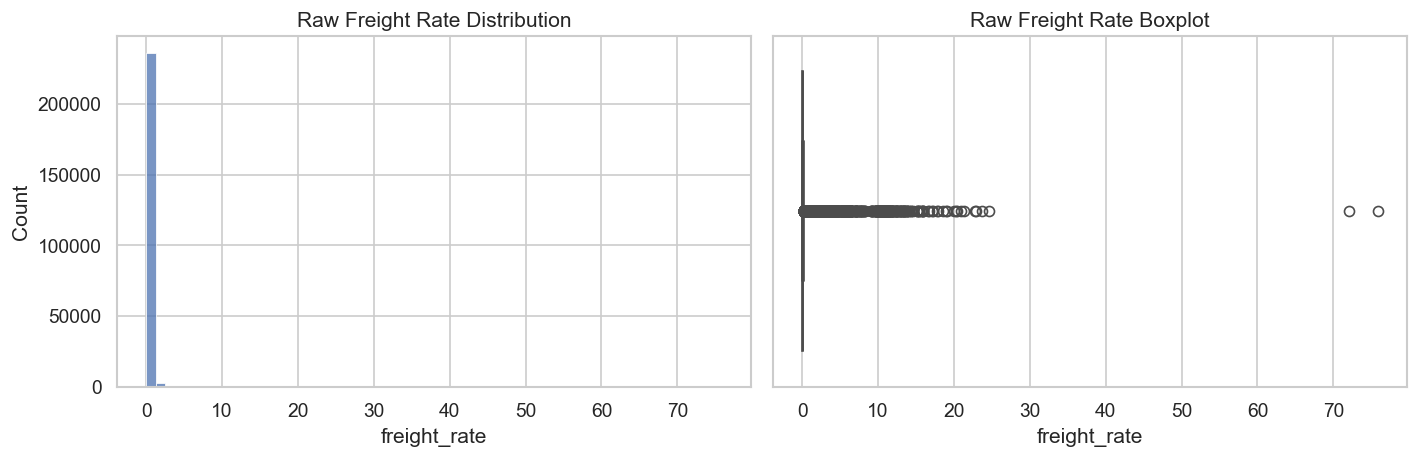

In [13]:
if TARGET_RAW in df_feat.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_feat[TARGET_RAW].dropna(), bins=60, ax=axes[0])
    axes[0].set_title("Raw Freight Rate Distribution")
    axes[0].set_xlabel(TARGET_RAW)

    sns.boxplot(x=df_feat[TARGET_RAW].dropna(), ax=axes[1])
    axes[1].set_title("Raw Freight Rate Boxplot")
    axes[1].set_xlabel(TARGET_RAW)
    plt.tight_layout()
    plt.show()

if TARGET_LOG in df_feat.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_feat[TARGET_LOG].dropna(), bins=60, ax=axes[0])
    axes[0].set_title("Log-Transformed Target Distribution")
    axes[0].set_xlabel(TARGET_LOG)

    sns.boxplot(x=df_feat[TARGET_LOG].dropna(), ax=axes[1])
    axes[1].set_title("Log-Transformed Target Boxplot")
    axes[1].set_xlabel(TARGET_LOG)
    plt.tight_layout()
    plt.show()


In [14]:
df_feat.columns

Index(['origin', 'destination', 'product_code', 'year', 'freight_rate',
       'lsbci_is_imputed', 'origin_teu_is_imputed', 'dest_teu_is_imputed',
       'lsbci', 'dist_km', 'lsci_o', 'lsci_d', 'lsci_sum', 'lsci_gap',
       'origin_teu', 'dest_teu', 'teu_log_product', 'origin_loaded_kt',
       'origin_discharged_kt', 'dest_loaded_kt', 'dest_discharged_kt',
       'trade_imbalance', 'origin_vessel_pct', 'dest_vessel_pct',
       'fleet_supply', 'historical_mean_rate',
       'historical_mean_rate_is_imputed', 'lsci_asymmetry', 'lsci_product',
       'lsbci_per_km', 'trade_intensity', 'port_pressure',
       'directional_imbalance', 'distance_lsci_interaction',
       'distance_fleet_interaction', 'capacity_gap', 'trade_exists',
       'post_covid', 'product_cat'],
      dtype='str')

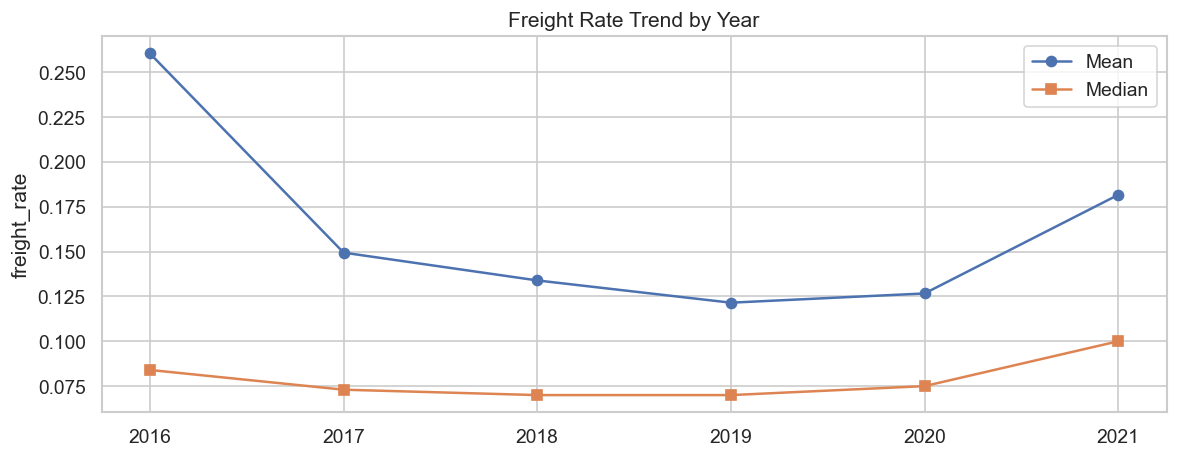

,year,mean,median,count
0,2016,0.260425,0.084,43911
1,2017,0.149408,0.073,37883
2,2018,0.133907,0.070,38819
3,2019,0.121500,0.070,39111
4,2020,0.126657,0.075,38970
5,2021,0.181606,0.100,40805


In [15]:
if {"year", TARGET_RAW}.issubset(df_feat.columns):
    yearly = df_feat.groupby("year")[TARGET_RAW].agg(["mean", "median", "count"]).reset_index()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(yearly["year"], yearly["mean"], marker="o", label="Mean")
    ax.plot(yearly["year"], yearly["median"], marker="s", label="Median")
    ax.set_title("Freight Rate Trend by Year")
    ax.set_ylabel(TARGET_RAW)
    ax.legend()
    plt.tight_layout()
    plt.show()
    display(yearly)


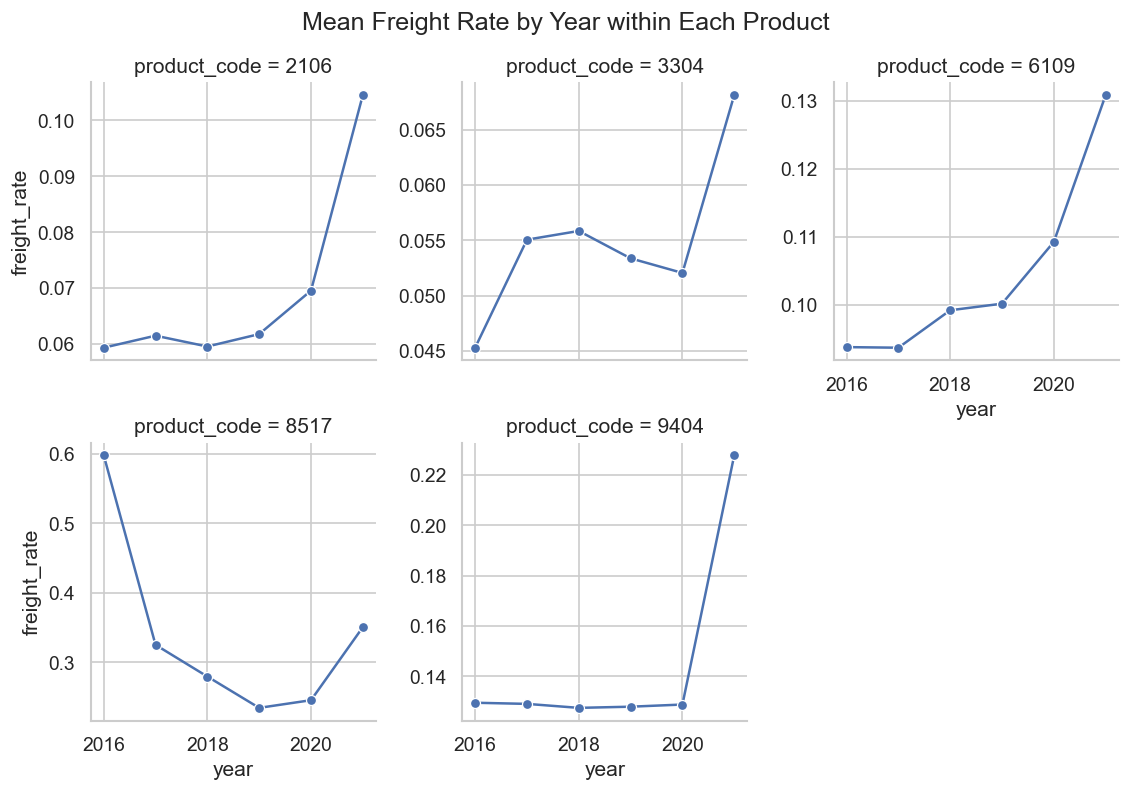

In [16]:
if {"year", "product_code", TARGET_RAW}.issubset(df_feat.columns):
    by_prod = df_feat.groupby(["year", "product_code"])[TARGET_RAW].mean().reset_index()
    g = sns.relplot(
        data=by_prod, x="year", y=TARGET_RAW, col="product_code", col_wrap=3,
        kind="line", marker="o", height=3.2, facet_kws={"sharey": False}
    )
    g.fig.suptitle("Mean Freight Rate by Year within Each Product", y=1.03)
    plt.show()


## 4. Feature family overview

This section checks whether the engineered variables are:
- heavily skewed,
- zero-inflated,
- dominated by outliers,
- or clean enough for tree-based models and interpretation.


In [17]:
feature_groups = {
    "Connectivity": [c for c in ["lsci_o", "lsci_d", "lsci_sum", "lsci_gap", "lsci_product", "lsbci", "lsbci_per_km"] if c in df_feat.columns],
    "Distance & fuel": [c for c in ["dist_km", "fuel_vlsfo_avg", "distance_lsci_interaction", "distance_fleet_interaction"] if c in df_feat.columns],
    "Port scale": [c for c in ["origin_teu", "dest_teu", "teu_log_product", "port_pressure"] if c in df_feat.columns],
    "Trade flow": [c for c in ["origin_loaded_kt", "dest_loaded_kt", "trade_imbalance", "directional_imbalance", "trade_intensity", "trade_exists"] if c in df_feat.columns],
    "Fleet": [c for c in ["origin_vessel_pct", "dest_vessel_pct", "fleet_supply", "capacity_gap"] if c in df_feat.columns],
    "History / controls": [c for c in ["historical_mean_rate", "historical_mean_rate_is_imputed", "post_covid", "product_cat"] if c in df_feat.columns],
}
feature_groups


{'Connectivity': ['lsci_o',
  'lsci_d',
  'lsci_sum',
  'lsci_gap',
  'lsci_product',
  'lsbci',
  'lsbci_per_km'],
 'Distance & fuel': ['dist_km',
  'distance_lsci_interaction',
  'distance_fleet_interaction'],
 'Port scale': ['origin_teu', 'dest_teu', 'teu_log_product', 'port_pressure'],
 'Trade flow': ['origin_loaded_kt',
  'dest_loaded_kt',
  'trade_imbalance',
  'directional_imbalance',
  'trade_intensity',
  'trade_exists'],
 'Fleet': ['origin_vessel_pct',
  'dest_vessel_pct',
  'fleet_supply',
  'capacity_gap'],
 'History / controls': ['historical_mean_rate',
  'historical_mean_rate_is_imputed',
  'post_covid',
  'product_cat']}

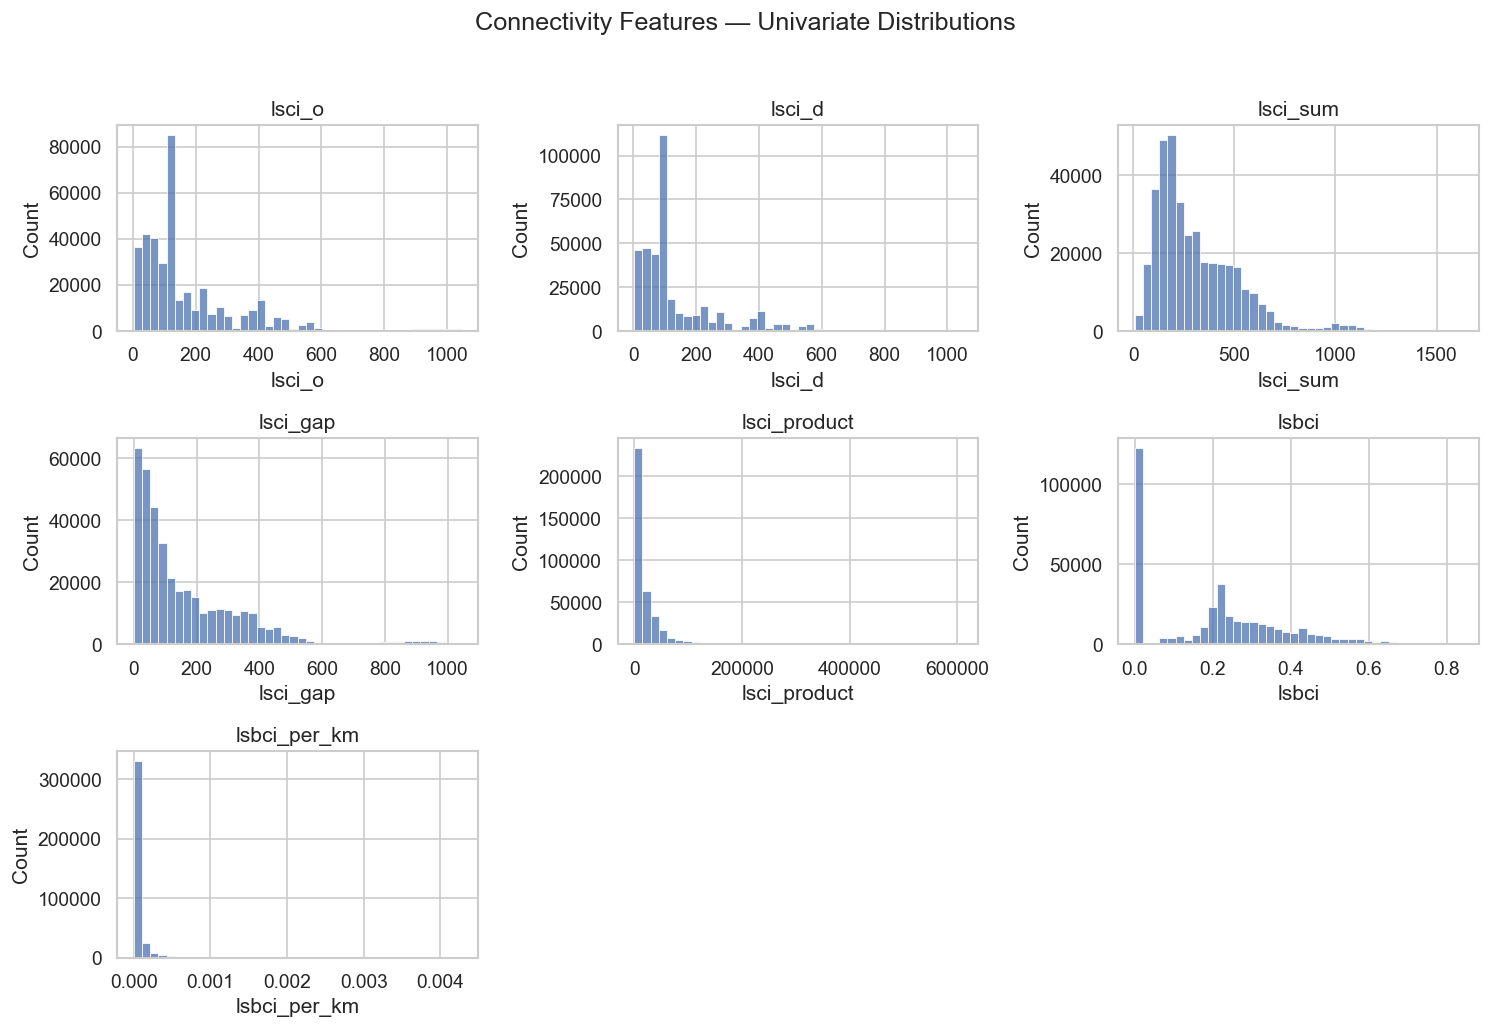

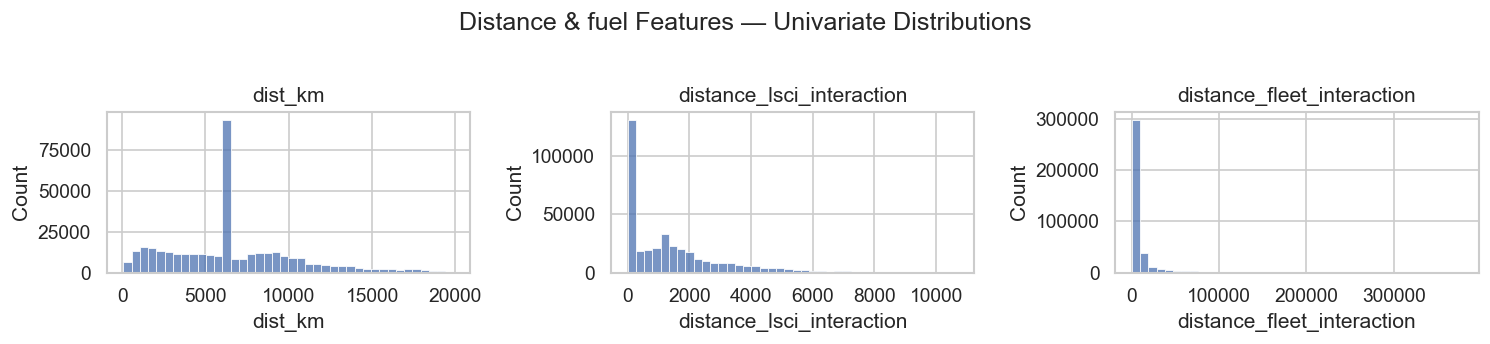

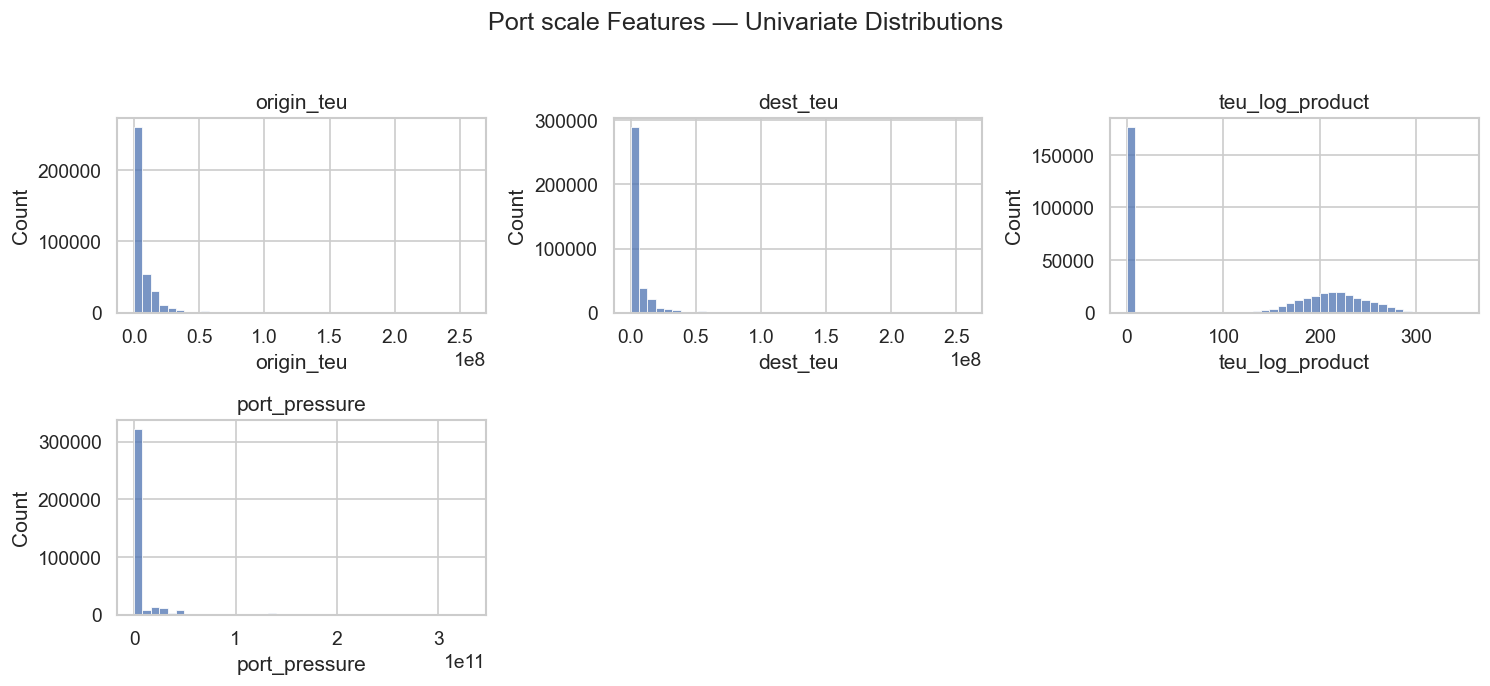

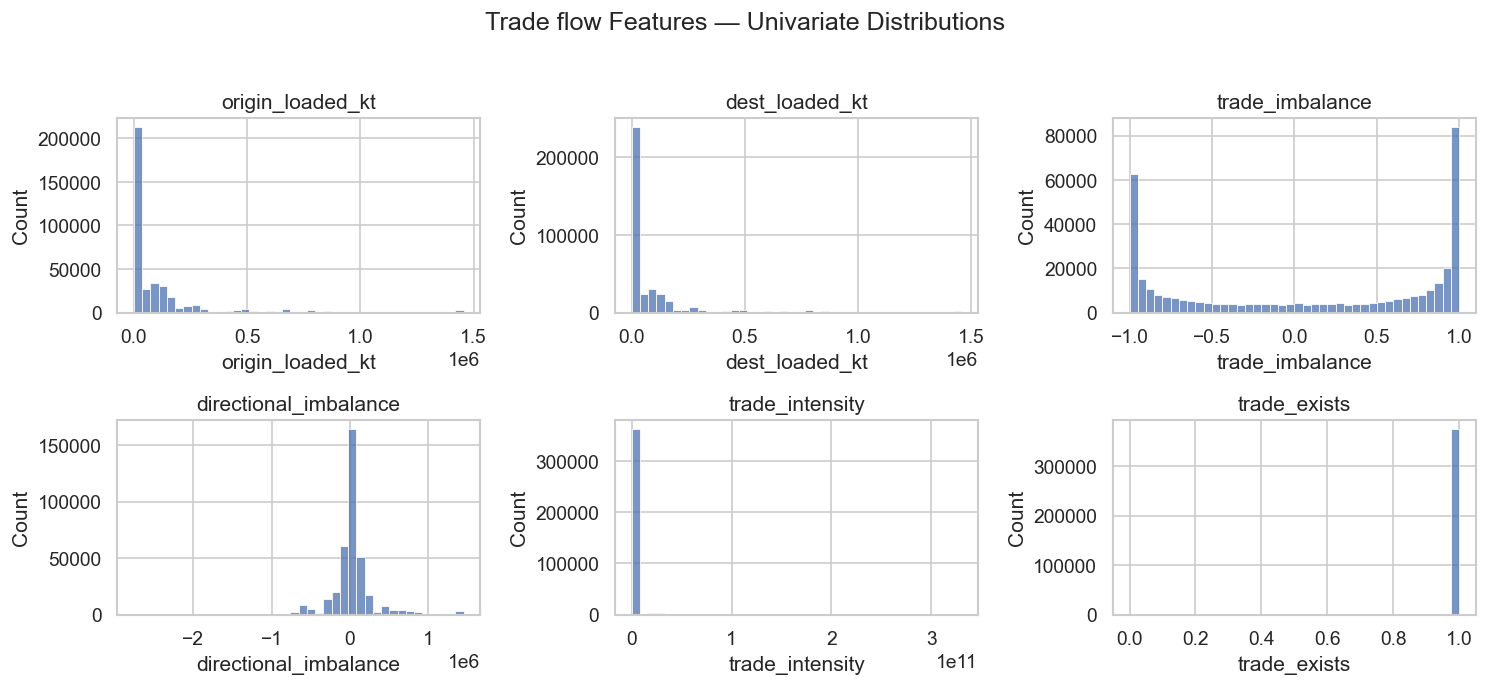

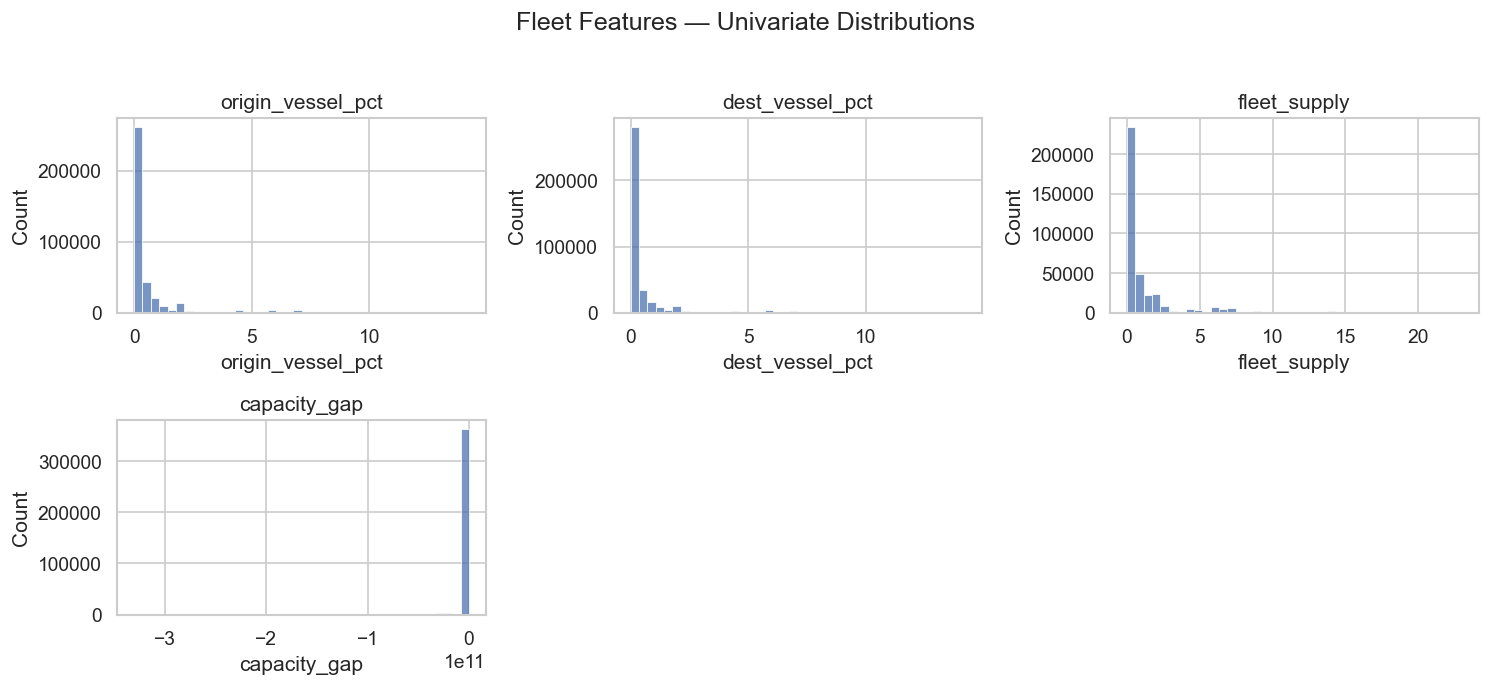

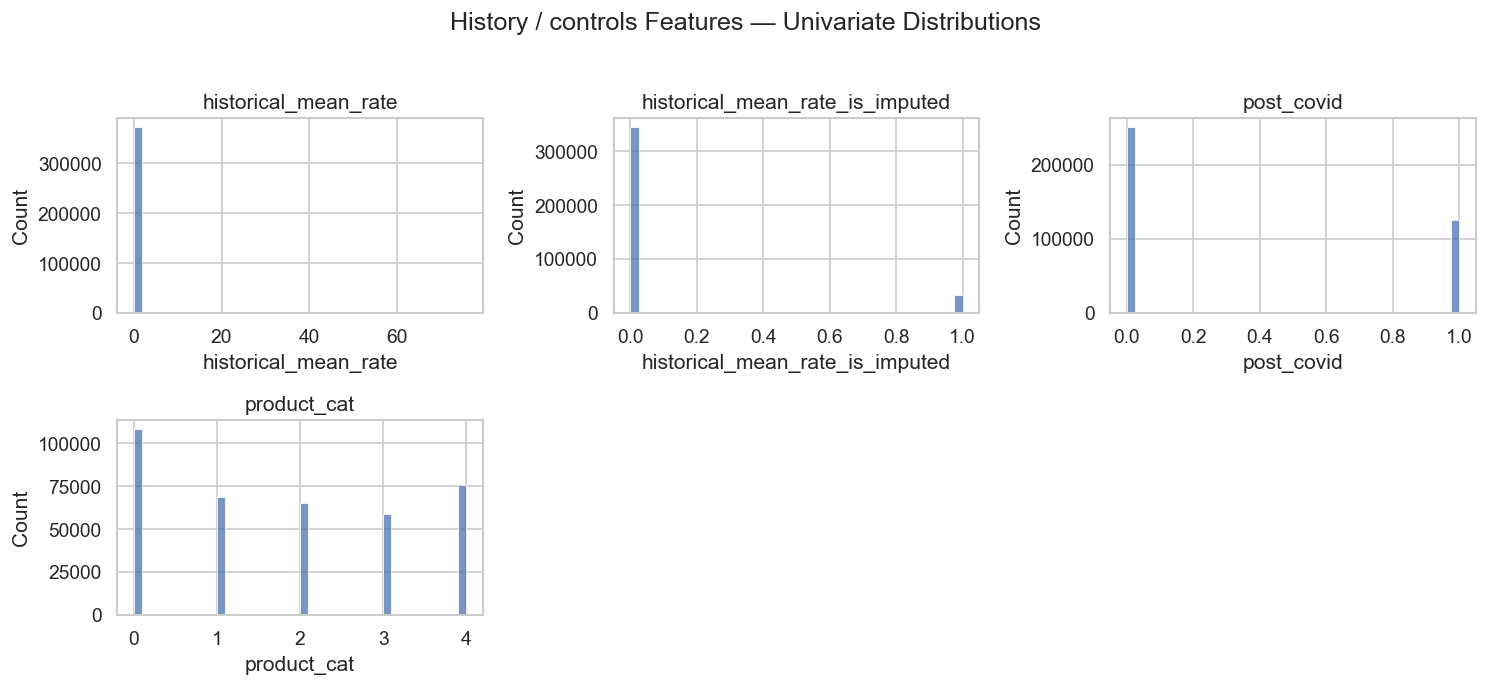

In [18]:
for group_name, cols in feature_groups.items():
    if not cols:
        continue
    n = len(cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 2.8*nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        sns.histplot(df_feat[col].dropna(), bins=40, ax=ax)
        ax.set_title(col)
    for ax in axes[len(cols):]:
        ax.axis("off")
    fig.suptitle(f"{group_name} Features — Univariate Distributions", y=1.02)
    plt.tight_layout()
    plt.show()


## 5. Which engineered features relate most strongly to the target?

For submission, this is one of the most important sections.  
Use it to justify that the engineered variables are not arbitrary.


In [19]:
analysis_target = TARGET_LOG if TARGET_LOG in df_feat.columns else TARGET_RAW
numeric_candidates = [c for c in present if pd.api.types.is_numeric_dtype(df_feat[c])]
corr_rows = []

for col in numeric_candidates:
    sub = df_feat[[col, analysis_target]].dropna()
    if len(sub) >= 20:
        corr_rows.append({
            "feature": col,
            "pearson_r": sub[col].corr(sub[analysis_target], method="pearson"),
            "spearman_r": sub[col].corr(sub[analysis_target], method="spearman"),
            "n": len(sub)
        })

corr_df = pd.DataFrame(corr_rows).sort_values("spearman_r", key=lambda s: s.abs(), ascending=False)
display(corr_df.head(20))


,feature,pearson_r,spearman_r,n
24,historical_mean_rate,0.815905,0.854260,239499
14,dest_loaded_kt,-0.060460,-0.202650,239499
21,dest_vessel_pct,-0.047971,-0.200337,239499
15,dest_discharged_kt,-0.046982,-0.198396,239499
30,product_cat,-0.152514,-0.188341,239499
10,dest_teu,-0.037252,-0.147620,239499
1,lsci_d,-0.071802,-0.143808,239499
16,trade_imbalance,0.036801,0.127936,239499
22,fleet_supply,-0.033948,-0.106306,239499
19,directional_imbalance,0.028639,0.104474,239499


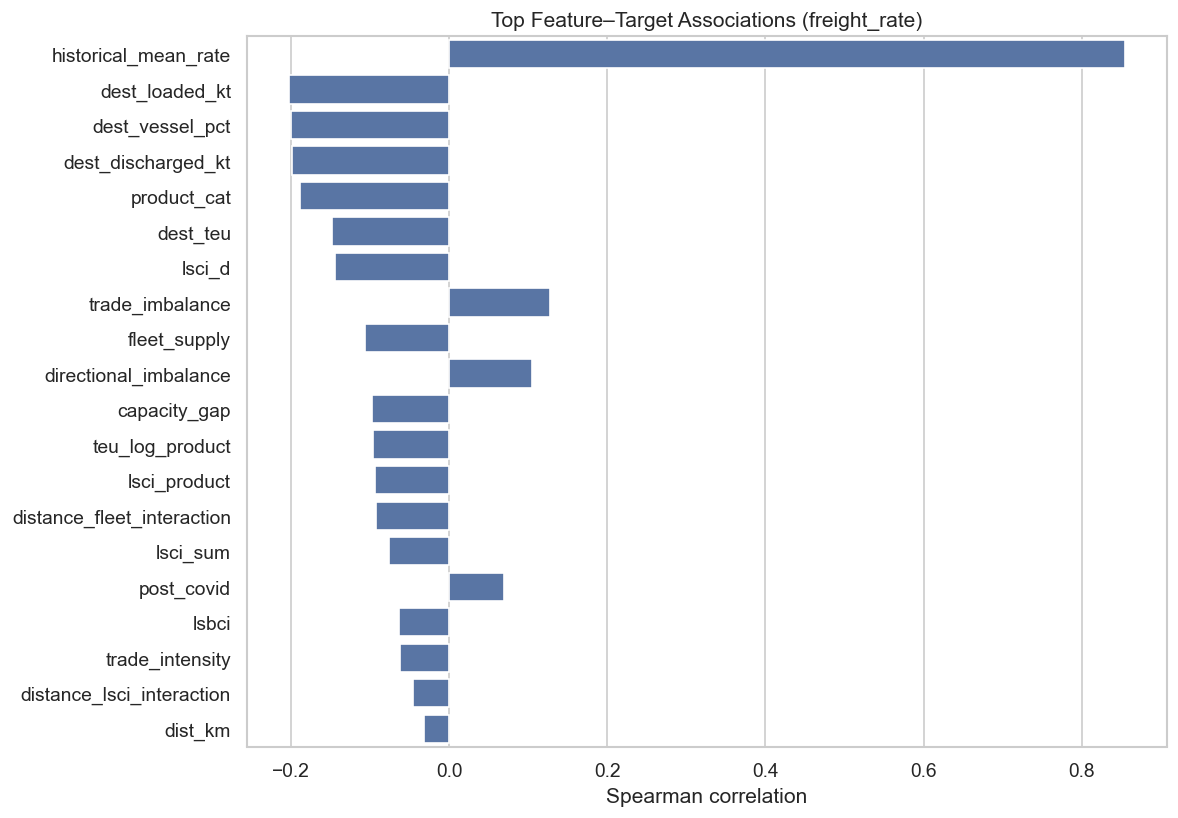

In [20]:
top_corr = corr_df.head(20).copy()
fig, ax = plt.subplots(figsize=(10, max(4, len(top_corr)*0.35)))
sns.barplot(data=top_corr, y="feature", x="spearman_r", ax=ax)
ax.set_title(f"Top Feature–Target Associations ({analysis_target})")
ax.set_xlabel("Spearman correlation")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 6. Binned relationship plots for engineered features

These are far more report-friendly than raw scatterplots because the dataset is large.  
They help you say things like:
- higher distance generally corresponds to higher rates,
- stronger bilateral connectivity tends to reduce or stabilize rates,
- stronger historical mean rate is strongly predictive,
- high imbalance is associated with pricing asymmetry and volatility.


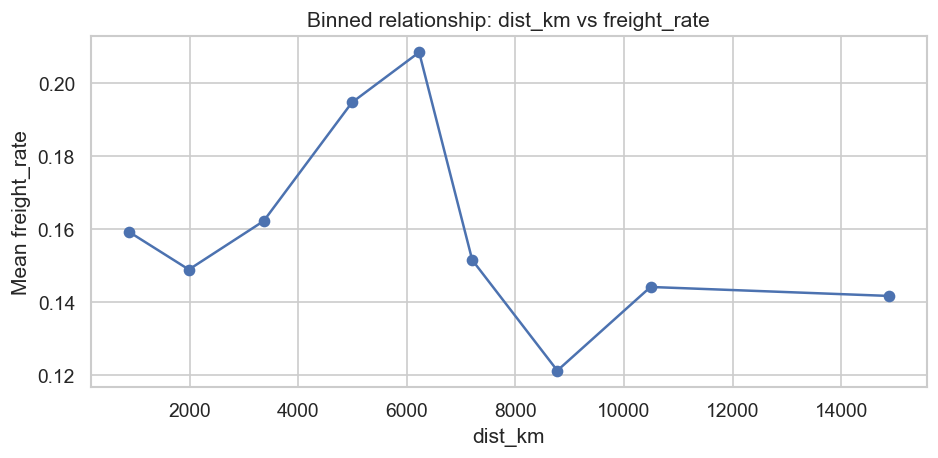

,feature_mean,target_mean,count
0,880.766068,0.159324,23967
1,1985.892485,0.148975,23940
2,3363.055745,0.162267,23957
3,4989.608177,0.194754,23940
4,6226.993501,0.208506,49402
5,7205.001397,0.151585,22480
6,8772.270619,0.121297,23934
7,10488.900338,0.144207,23941
8,14874.477424,0.141752,23938


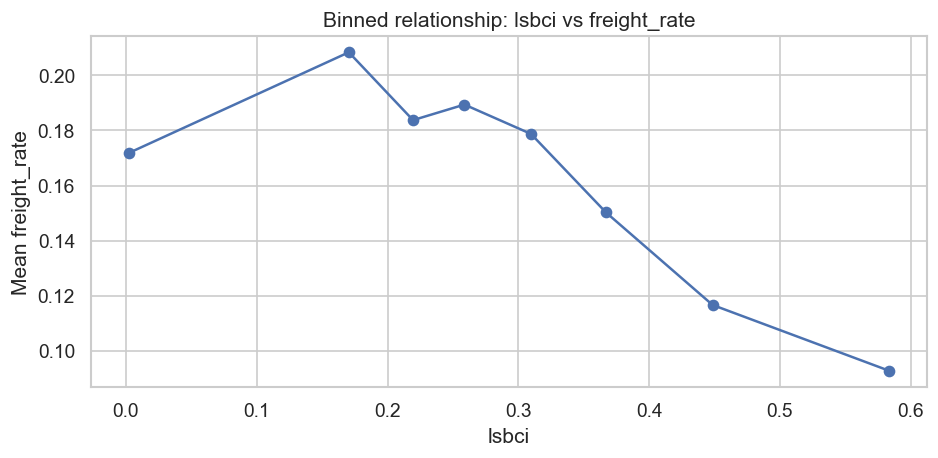

,feature_mean,target_mean,count
0,0.002202,0.171838,72690
1,0.170370,0.208414,26447
2,0.219465,0.183762,22312
3,0.258772,0.189412,25011
4,0.309642,0.178759,23382
5,0.366988,0.150232,23782
6,0.448491,0.116619,22768
7,0.583101,0.092781,23107


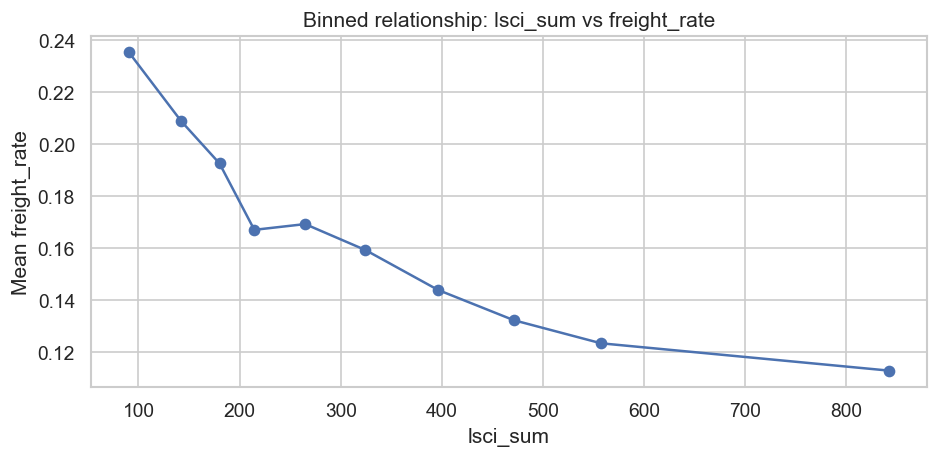

,feature_mean,target_mean,count
0,90.507342,0.235380,23954
1,142.221147,0.208873,23946
2,180.134533,0.192595,23954
3,214.549120,0.167026,24011
4,264.830154,0.169240,23886
5,324.387465,0.159260,24044
6,396.297655,0.143878,23866
7,471.135952,0.132242,23939
8,557.415132,0.123351,23954
9,841.827344,0.112845,23945


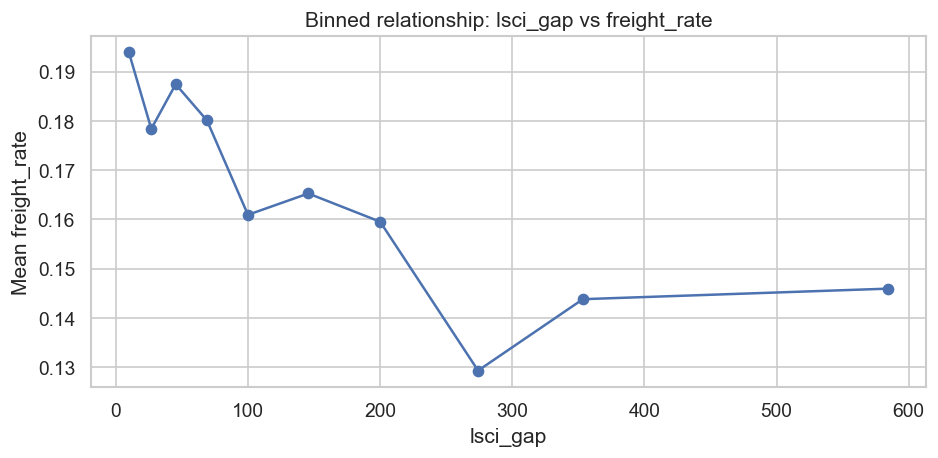

,feature_mean,target_mean,count
0,9.919686,0.193942,24001
1,26.900232,0.178394,23943
2,45.357846,0.187457,23907
3,69.008796,0.180110,23953
4,100.034486,0.160943,23952
5,145.709509,0.165275,23945
6,200.071395,0.159540,23949
7,274.162962,0.129318,23957
8,353.490197,0.143816,23949
9,584.579502,0.145955,23943


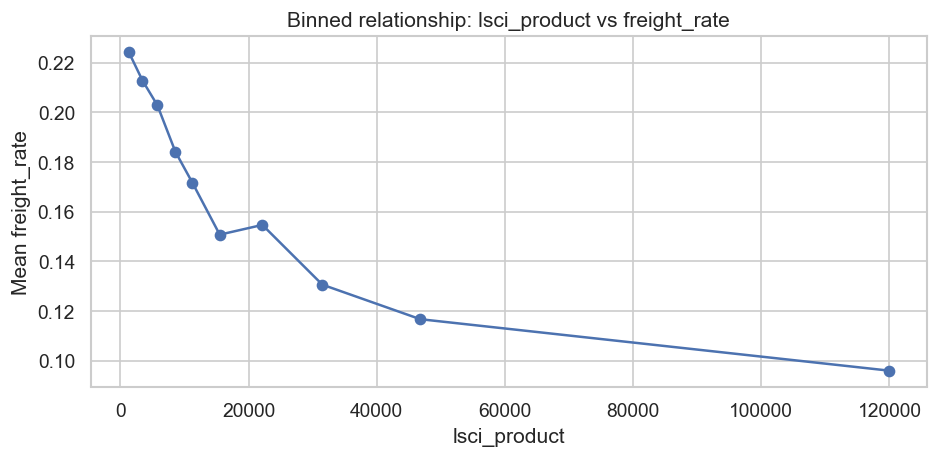

,feature_mean,target_mean,count
0,1327.116754,0.224206,23979
1,3452.335125,0.212818,23948
2,5779.120207,0.202850,23923
3,8581.645154,0.184149,24961
4,11247.550920,0.171608,22948
5,15506.437659,0.150726,23940
6,22156.492077,0.154647,23953
7,31515.477562,0.130576,23952
8,46794.496911,0.116660,23945
9,119874.386408,0.095956,23950


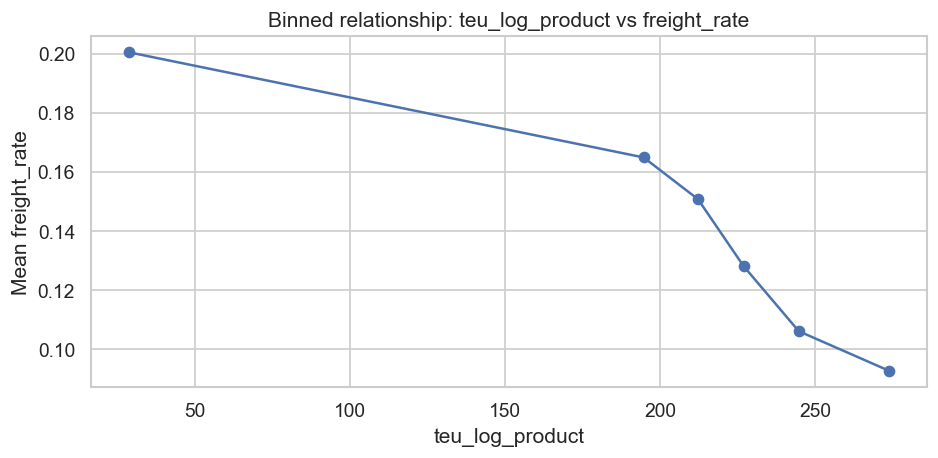

,feature_mean,target_mean,count
0,28.737396,0.200481,119750
1,194.744344,0.164869,23950
2,212.278332,0.150714,23950
3,226.966609,0.128072,23953
4,244.791190,0.106005,23954
5,273.756460,0.092689,23942


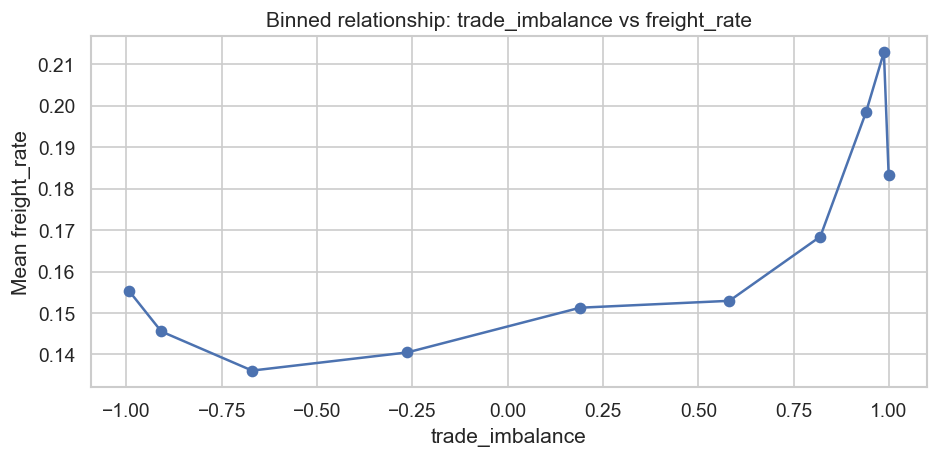

,feature_mean,target_mean,count
0,-0.993388,0.155369,23950
1,-0.908362,0.145529,23952
2,-0.670283,0.136084,23952
3,-0.263039,0.140471,23948
4,0.189945,0.151261,23950
5,0.581443,0.152925,23951
6,0.819977,0.168441,23947
7,0.939622,0.198417,23950
8,0.986610,0.212917,23953
9,0.999098,0.183350,23946


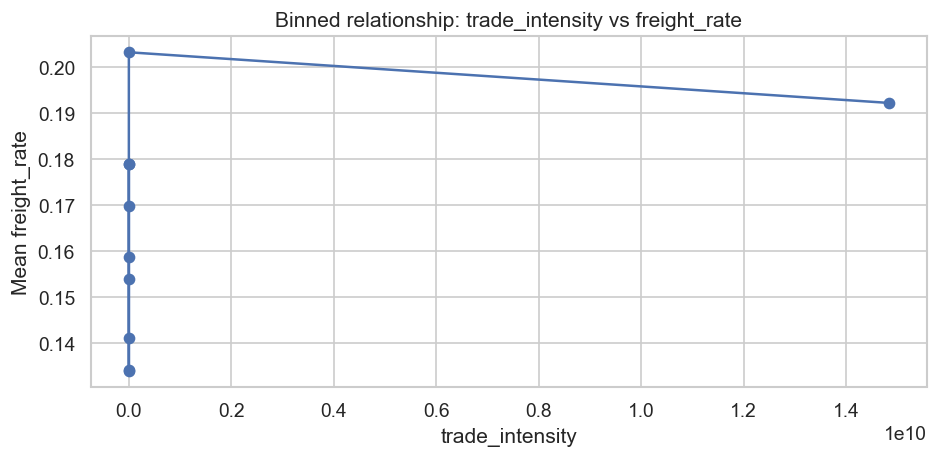

,feature_mean,target_mean,count
0,1.864987e-03,0.178824,23950
1,4.863889e-03,0.178895,23958
2,7.238549e-03,0.169851,23943
3,9.533892e-03,0.158669,23949
4,1.319158e-02,0.141029,23950
5,1.654385e-02,0.134196,23953
6,2.256410e-02,0.134016,23949
7,3.465973e-02,0.153861,23957
8,6.561737e-02,0.203224,23944
9,1.483318e+10,0.192215,23946


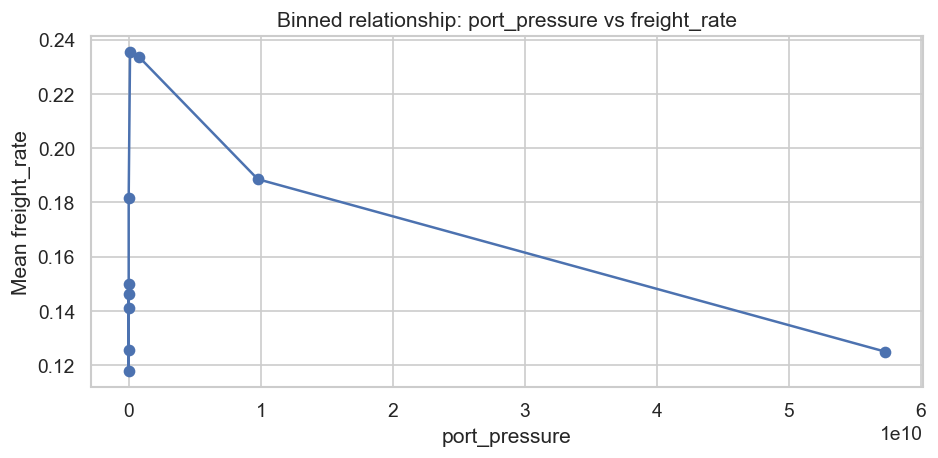

,feature_mean,target_mean,count
0,6.592634e-03,0.150021,23950
1,1.462879e-02,0.146359,23950
2,2.305711e-02,0.125429,23950
3,3.611647e-02,0.118004,23953
4,5.728250e-02,0.140919,23947
5,1.278351e-01,0.181682,23955
6,1.032526e+08,0.235333,23945
7,8.177606e+08,0.233443,23955
8,9.772780e+09,0.188563,23946
9,5.726497e+10,0.125011,23948


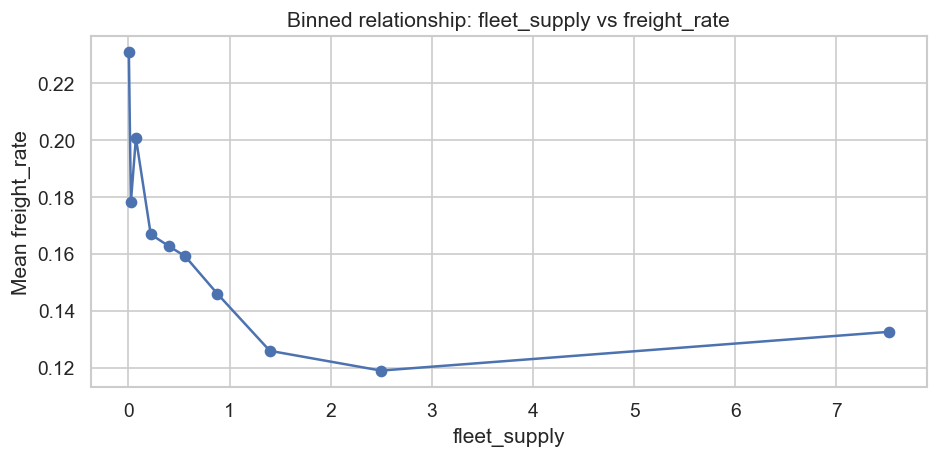

,feature_mean,target_mean,count
0,0.004198,0.230869,34391
1,0.024113,0.178096,15630
2,0.073820,0.200765,22652
3,0.220603,0.166827,25253
4,0.402040,0.162644,24222
5,0.560315,0.159132,21760
6,0.878270,0.145977,24086
7,1.397554,0.125881,23642
8,2.496337,0.118925,24267
9,7.515819,0.132545,23596


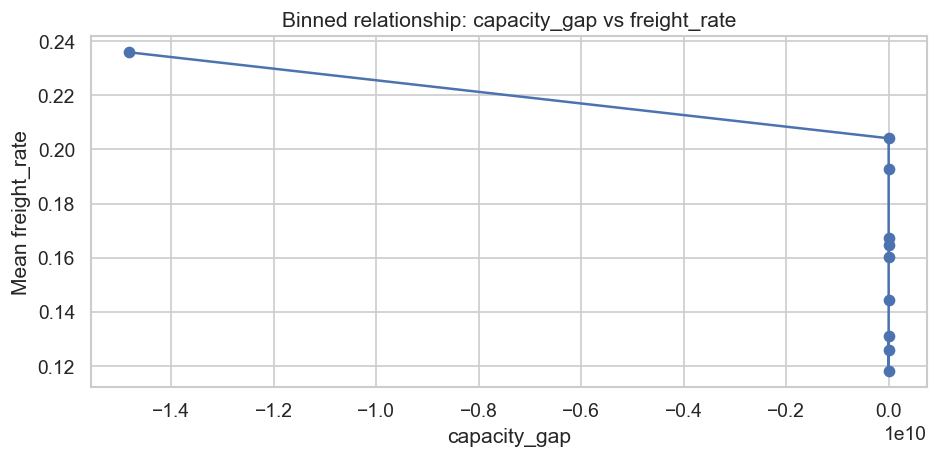

,feature_mean,target_mean,count
0,-1.482885e+10,0.235877,23953
1,-6.200546e-03,0.204102,23949
2,3.772190e-02,0.192721,23948
3,1.763221e-01,0.164746,23953
4,3.698437e-01,0.167315,23948
5,5.118339e-01,0.160231,23949
6,8.288339e-01,0.144346,23952
7,1.361266e+00,0.126002,23952
8,2.428868e+00,0.118265,23951
9,7.451974e+00,0.131153,23944


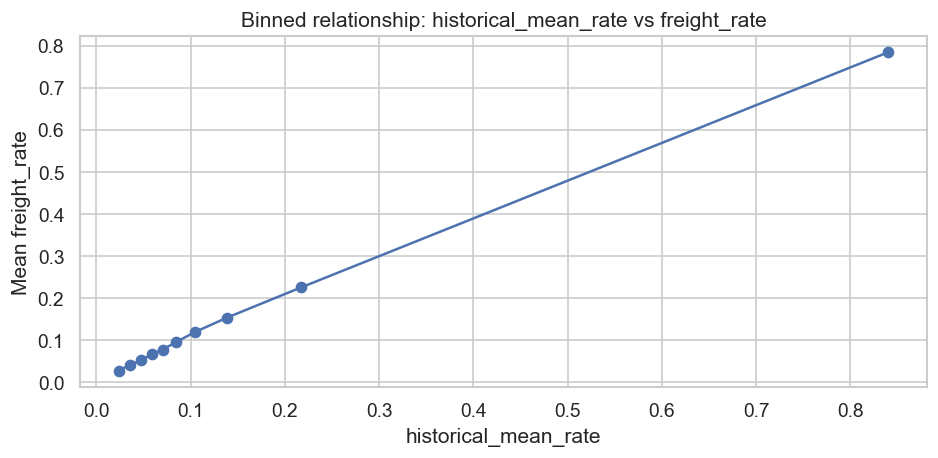

,feature_mean,target_mean,count
0,0.023515,0.028027,24018
1,0.035559,0.041080,23976
2,0.047202,0.052703,23886
3,0.058764,0.066808,24175
4,0.070412,0.078048,23719
5,0.084753,0.096034,24022
6,0.104437,0.119433,23886
7,0.138528,0.153780,23950
8,0.217017,0.225373,23920
9,0.840224,0.784023,23947


In [21]:
def binned_target_plot(df, feature, target, q=10, min_unique=8):
    d = df[[feature, target]].dropna().copy()
    if d.empty or d[feature].nunique() < min_unique:
        print(f"Skipping {feature}: insufficient unique values.")
        return
    try:
        d["bin"] = pd.qcut(d[feature], q=q, duplicates="drop")
    except Exception:
        print(f"Skipping {feature}: qcut failed.")
        return
    summary = d.groupby("bin").agg(
        feature_mean=(feature, "mean"),
        target_mean=(target, "mean"),
        count=(target, "size")
    ).reset_index(drop=True)

    fig, ax1 = plt.subplots(figsize=(8, 4))
    ax1.plot(summary["feature_mean"], summary["target_mean"], marker="o")
    ax1.set_xlabel(feature)
    ax1.set_ylabel(f"Mean {target}")
    ax1.set_title(f"Binned relationship: {feature} vs {target}")
    plt.tight_layout()
    plt.show()
    display(summary)

priority_features = [c for c in [
    "dist_km", "fuel_vlsfo_avg", "lsbci", "lsci_sum", "lsci_gap", "lsci_product",
    "teu_log_product", "trade_imbalance", "trade_intensity", "port_pressure",
    "fleet_supply", "capacity_gap", "historical_mean_rate"
] if c in df_feat.columns]

for feat in priority_features:
    binned_target_plot(df_feat, feat, analysis_target)


## 7. Product-wise heterogeneity

A feature may be useful overall but behave differently by product category.  
This is especially important for route-level tariff/freight data, where bulkier or lower-value products can react differently to distance, congestion, and connectivity.


,product_code,feature,spearman_r,n
0,2106,dist_km,0.033465,46173
1,2106,lsbci,0.003207,46173
2,2106,lsci_sum,0.022888,46173
3,2106,lsci_gap,0.031479,46173
4,2106,lsci_product,0.012191,46173
5,2106,teu_log_product,-0.011046,46173
6,2106,trade_imbalance,0.183176,46173
7,2106,trade_intensity,-0.073850,46173
8,2106,port_pressure,-0.014125,46173
9,2106,fleet_supply,-0.053833,46173


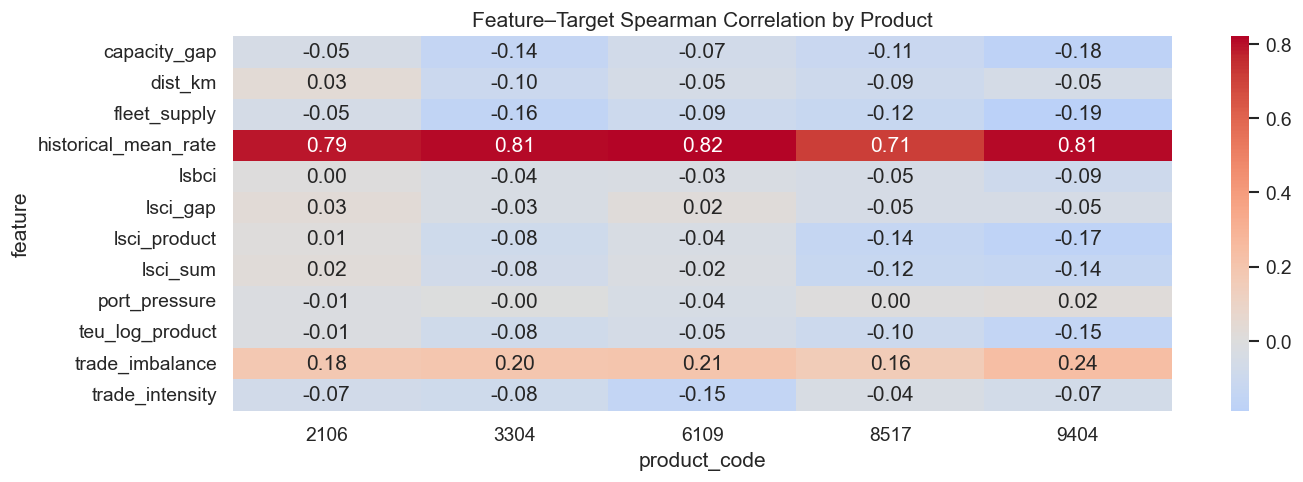

In [22]:
if "product_code" in df_feat.columns:
    product_corr_rows = []
    for prod, g in df_feat.groupby("product_code"):
        for feat in priority_features:
            if feat not in g.columns:
                continue
            sub = g[[feat, analysis_target]].dropna()
            if len(sub) >= 20 and sub[feat].nunique() >= 5:
                product_corr_rows.append({
                    "product_code": prod,
                    "feature": feat,
                    "spearman_r": sub[feat].corr(sub[analysis_target], method="spearman"),
                    "n": len(sub)
                })
    product_corr_df = pd.DataFrame(product_corr_rows)
    display(product_corr_df.head(20))

    if not product_corr_df.empty:
        pivot = product_corr_df.pivot(index="feature", columns="product_code", values="spearman_r")
        plt.figure(figsize=(12, max(4, len(pivot)*0.35)))
        sns.heatmap(pivot, cmap="coolwarm", center=0, annot=True, fmt=".2f")
        plt.title("Feature–Target Spearman Correlation by Product")
        plt.tight_layout()
        plt.show()


## 8. Interaction-feature validation

These plots justify why interaction terms were engineered instead of relying only on raw variables.


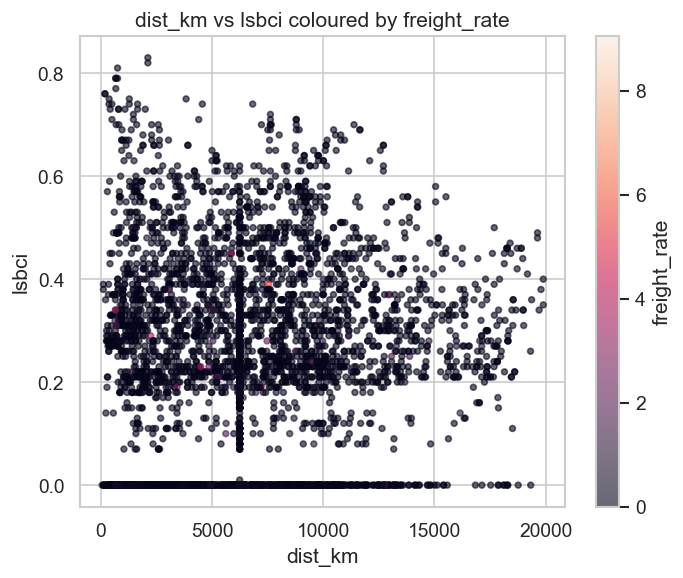

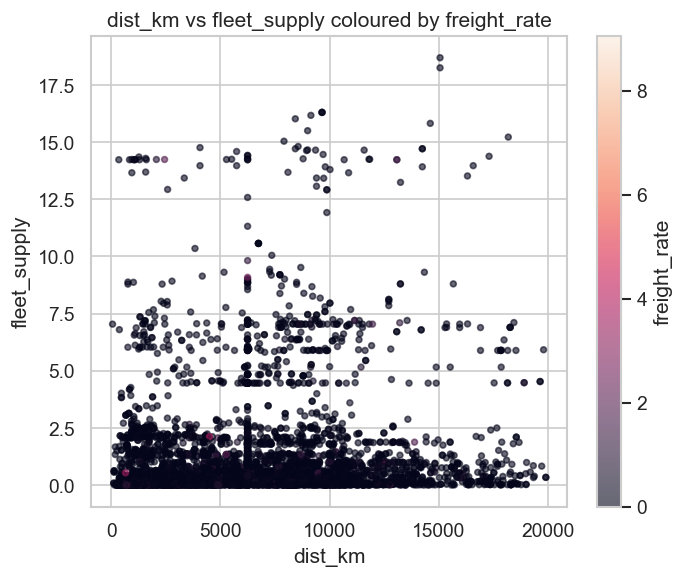

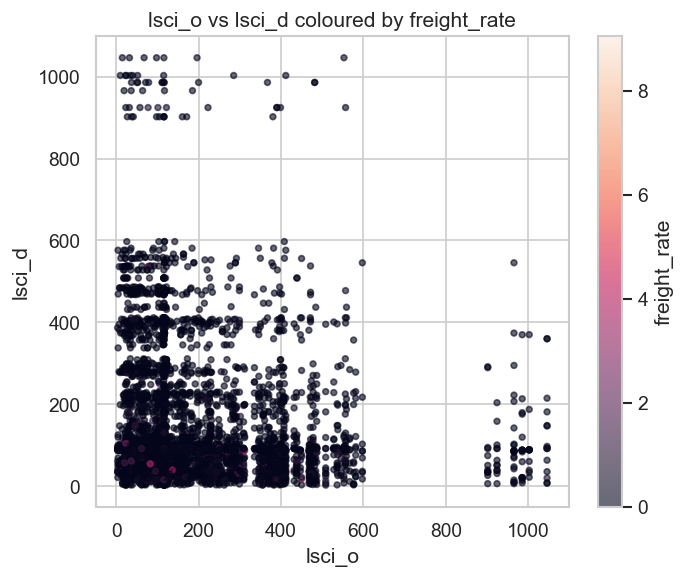

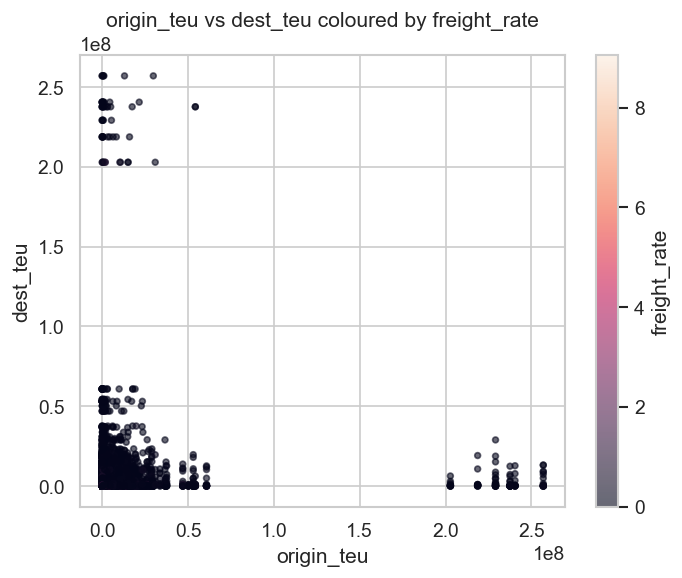

In [23]:
interaction_specs = [
    ("dist_km", "lsbci", "distance_lsci_interaction"),
    ("dist_km", "fleet_supply", "distance_fleet_interaction"),
    ("lsci_o", "lsci_d", "lsci_product"),
    ("origin_teu", "dest_teu", "teu_log_product"),
]

for x, y, hue_col in interaction_specs:
    if not set([x, y, hue_col, analysis_target]).issubset(df_feat.columns):
        continue
    d = df_feat[[x, y, hue_col, analysis_target]].dropna().copy()
    if len(d) > 5000:
        d = d.sample(5000, random_state=42)
    fig, ax = plt.subplots(figsize=(6, 5))
    sc = ax.scatter(d[x], d[y], c=d[analysis_target], s=12, alpha=0.6)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y} coloured by {analysis_target}")
    plt.colorbar(sc, ax=ax, label=analysis_target)
    plt.tight_layout()
    plt.show()


## 9. Imbalance features: are they economically sensible?

These plots are especially useful for your report because they connect the feature engineering back to shipping economics:
- stronger imbalance should often imply higher cost pressure or more volatile rates,
- balanced routes should usually look more stable.


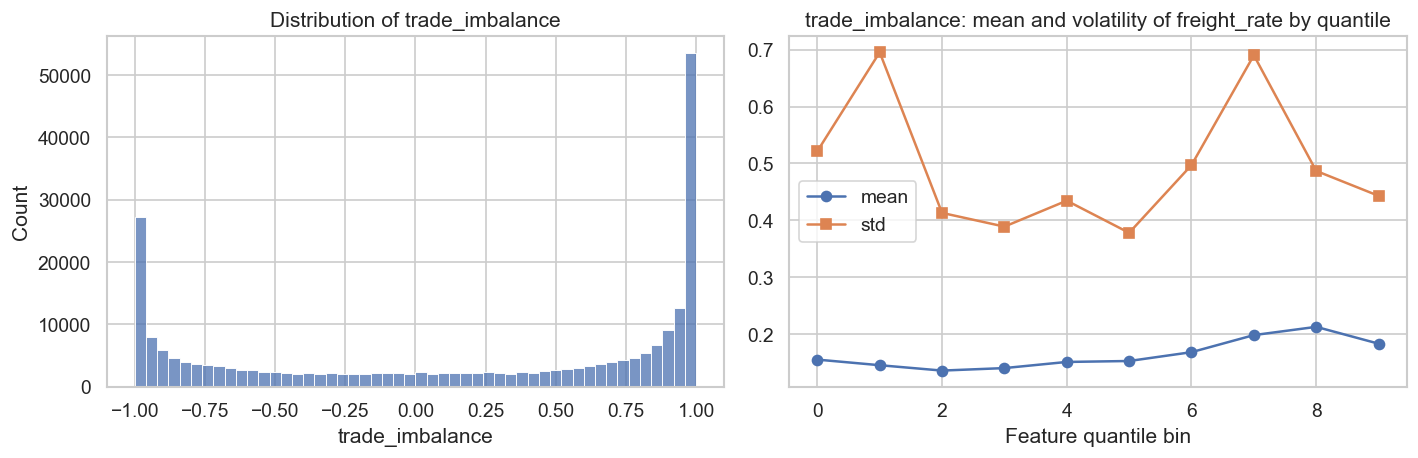

,bin,mean,median,std,count
0,"(-1.001, -0.972]",0.155369,0.072,0.521461,23950
1,"(-0.972, -0.816]",0.145529,0.069,0.695285,23952
2,"(-0.816, -0.495]",0.136084,0.069,0.413099,23952
3,"(-0.495, -0.0313]",0.140471,0.071,0.389014,23948
4,"(-0.0313, 0.408]",0.151261,0.074,0.434575,23950
5,"(0.408, 0.722]",0.152925,0.077,0.378106,23951
6,"(0.722, 0.896]",0.168441,0.082,0.497056,23947
7,"(0.896, 0.972]",0.198417,0.090,0.690050,23950
8,"(0.972, 0.996]",0.212917,0.100,0.486829,23953
9,"(0.996, 1.0]",0.183350,0.084,0.443103,23946


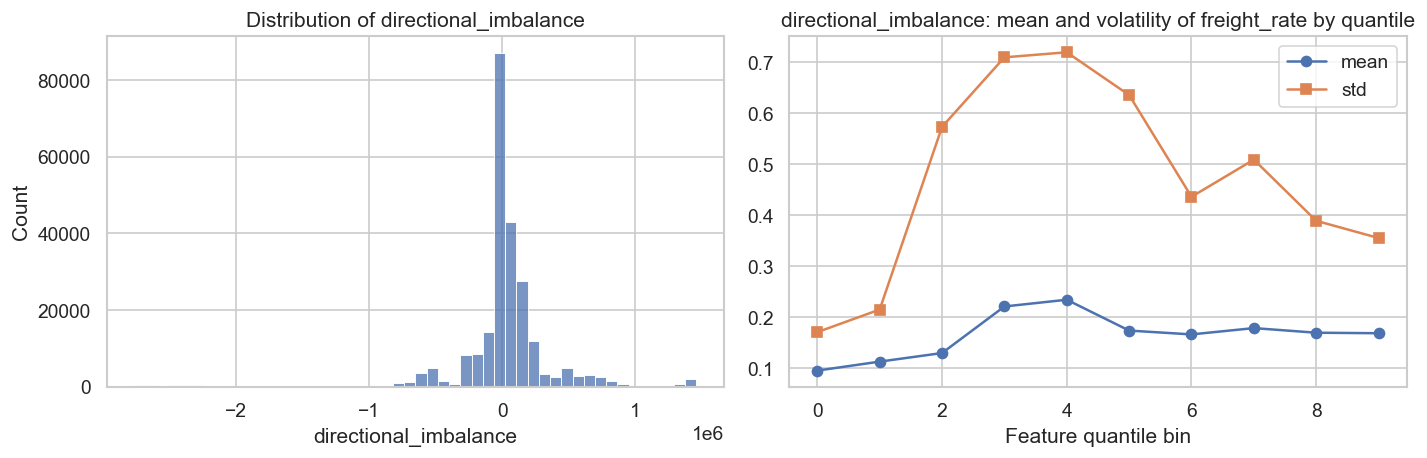

,bin,mean,median,std,count
0,"(-2760376.001, -226471.6]",0.094720,0.065,0.170213,23950
1,"(-226471.6, -55332.0]",0.112327,0.070,0.214548,23953
2,"(-55332.0, -17009.4]",0.129155,0.070,0.573152,23947
3,"(-17009.4, -1214.2]",0.220557,0.086,0.709616,23950
4,"(-1214.2, 10784.0]",0.233795,0.088,0.719533,23951
5,"(10784.0, 41065.8]",0.173260,0.078,0.635553,23948
6,"(41065.8, 90121.8]",0.165734,0.082,0.435861,23950
7,"(90121.8, 141380.0]",0.178109,0.083,0.508831,23953
8,"(141380.0, 274342.0]",0.169052,0.082,0.388719,23948
9,"(274342.0, 1455984.0]",0.168053,0.086,0.354945,23949


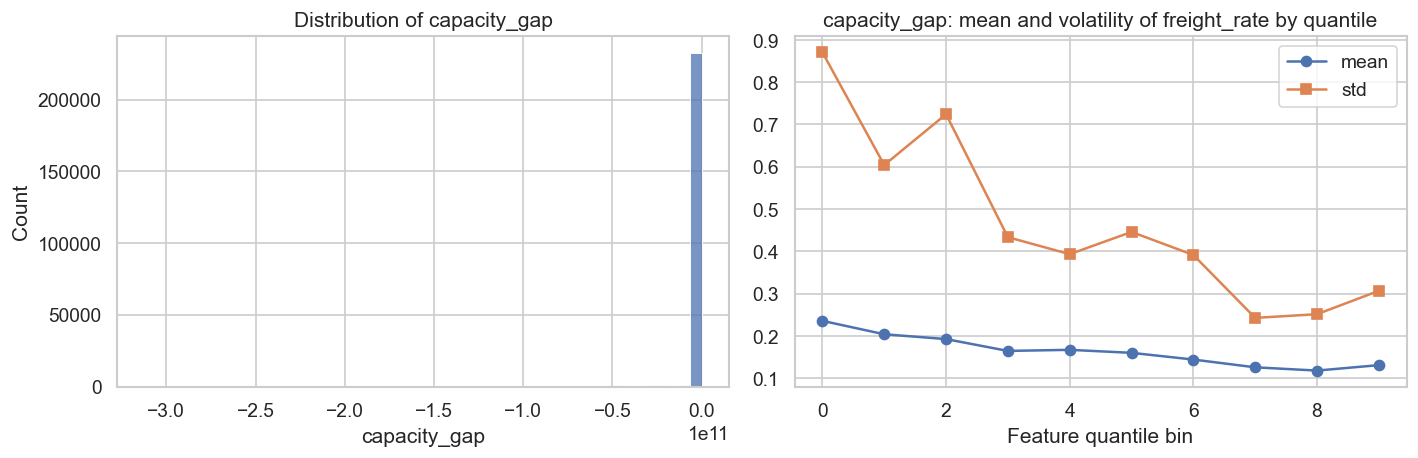

,bin,mean,median,std,count
0,"(-311839999999.891, -0.0275]",0.235877,0.083,0.870694,23953
1,"(-0.0275, 0.00746]",0.204102,0.089,0.604123,23949
2,"(0.00746, 0.0774]",0.192721,0.085,0.724252,23948
3,"(0.0774, 0.3]",0.164746,0.081,0.433651,23953
4,"(0.3, 0.441]",0.167315,0.082,0.393445,23948
5,"(0.441, 0.594]",0.160231,0.077,0.446011,23949
6,"(0.594, 0.997]",0.144346,0.077,0.391559,23952
7,"(0.997, 1.795]",0.126002,0.072,0.242826,23952
8,"(1.795, 4.458]",0.118265,0.065,0.251555,23951
9,"(4.458, 23.009]",0.131153,0.074,0.306797,23944


In [24]:
imbalance_cols = [c for c in ["trade_imbalance", "directional_imbalance", "capacity_gap"] if c in df_feat.columns]

for feat in imbalance_cols:
    d = df_feat[[feat, analysis_target]].dropna().copy()
    if d.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(d[feat], bins=50, ax=axes[0])
    axes[0].set_title(f"Distribution of {feat}")

    try:
        d["bin"] = pd.qcut(d[feat], q=10, duplicates="drop")
        summary = d.groupby("bin")[analysis_target].agg(["mean", "median", "std", "count"]).reset_index()
        axes[1].plot(range(len(summary)), summary["mean"], marker="o", label="mean")
        axes[1].plot(range(len(summary)), summary["std"], marker="s", label="std")
        axes[1].set_title(f"{feat}: mean and volatility of {analysis_target} by quantile")
        axes[1].set_xlabel("Feature quantile bin")
        axes[1].legend()
        plt.tight_layout()
        plt.show()
        display(summary)
    except Exception:
        plt.tight_layout()
        plt.show()


## 10. Imputation diagnostics

This is a missing piece in your current EDA.  
Because several engineered variables are imputed, the report should explicitly check whether imputed observations have very different distributions from non-imputed observations.


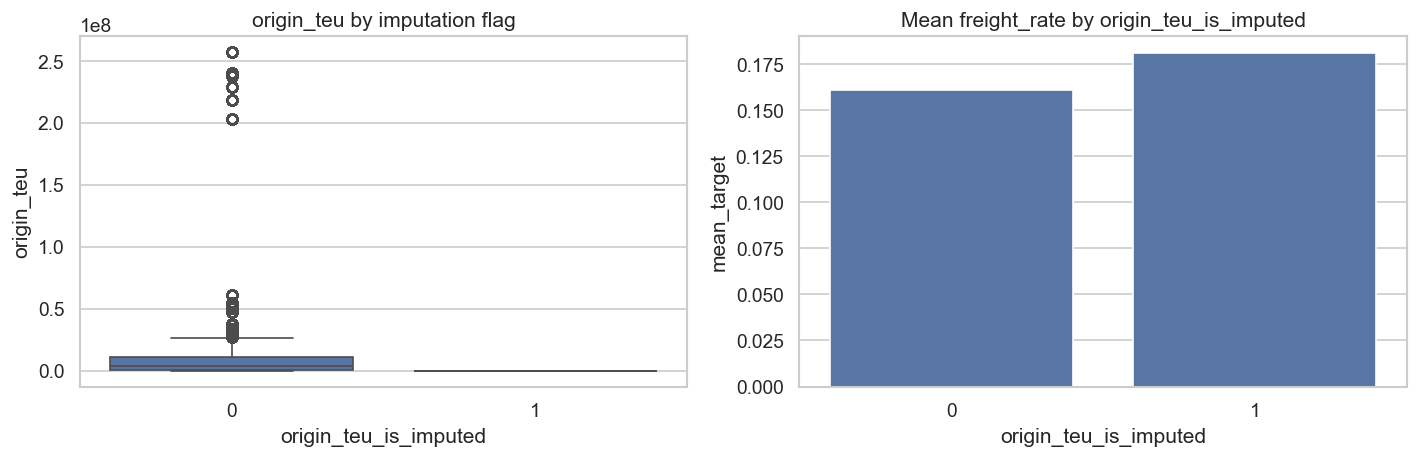

,origin_teu_is_imputed,mean_value,median_value,mean_target,n
0,0,1.431206e+07,5727822.0,0.161019,197962
1,1,0.000000e+00,0.0,0.180953,41537


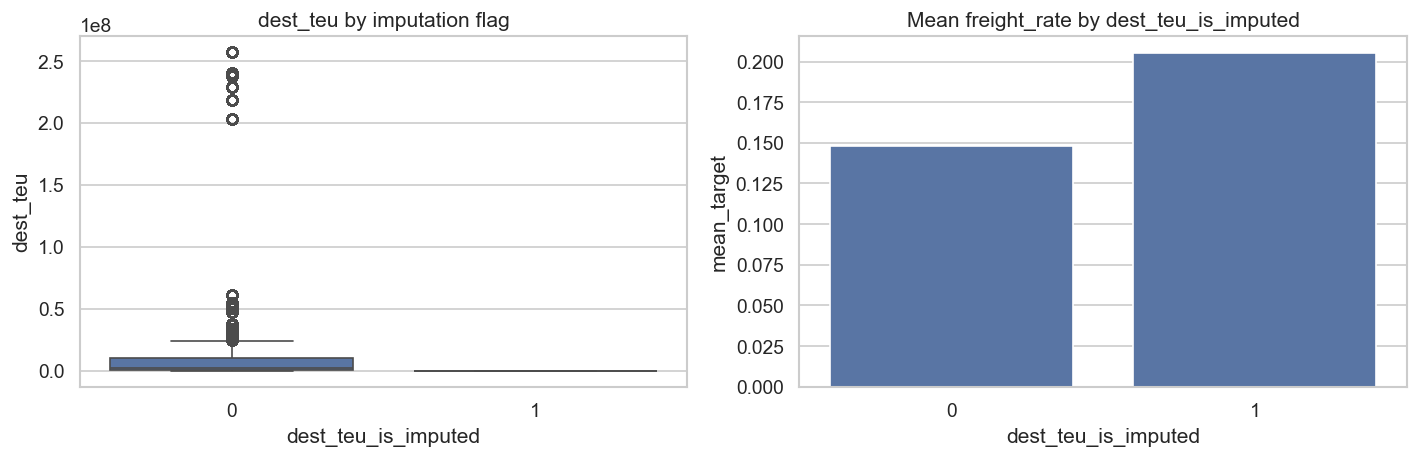

,dest_teu_is_imputed,mean_value,median_value,mean_target,n
0,0,1.048105e+07,2321062.0,0.148135,170946
1,1,0.000000e+00,0.0,0.205225,68553


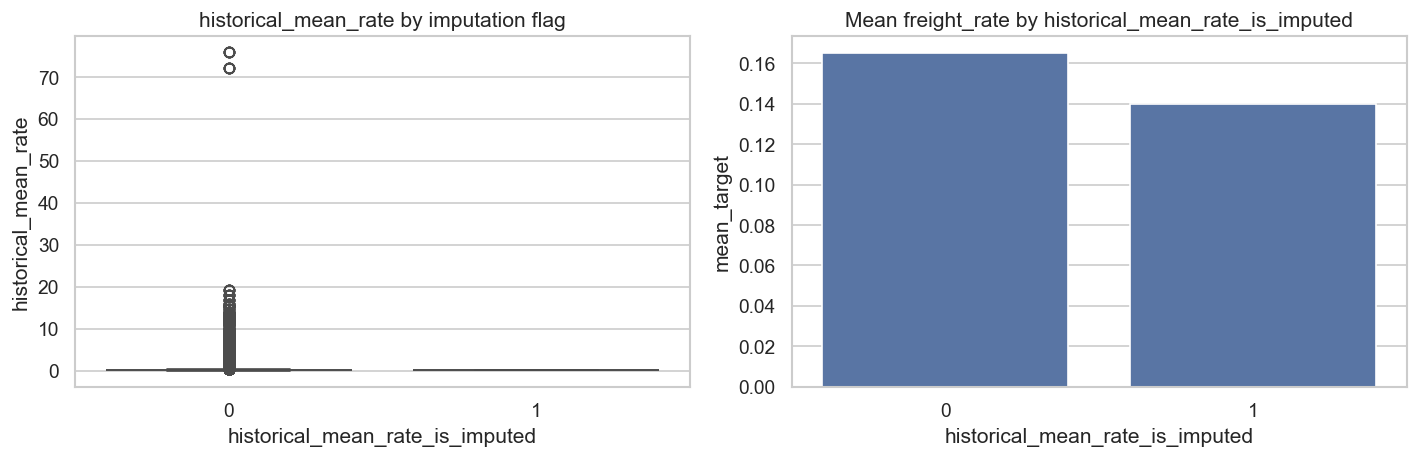

,historical_mean_rate_is_imputed,mean_value,median_value,mean_target,n
0,0,0.164361,0.07725,0.165159,233020
1,1,0.076586,0.07900,0.139937,6479


In [25]:
imputation_pairs = [
    ("origin_teu", "origin_teu_is_imputed"),
    ("dest_teu", "dest_teu_is_imputed"),
    ("historical_mean_rate", "historical_mean_rate_is_imputed"),
]

for value_col, flag_col in imputation_pairs:
    if not set([value_col, flag_col]).issubset(df_feat.columns):
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=df_feat[[value_col, flag_col]].dropna(), x=flag_col, y=value_col, ax=axes[0])
    axes[0].set_title(f"{value_col} by imputation flag")

    d = df_feat[[value_col, flag_col, analysis_target]].dropna()
    summary = d.groupby(flag_col).agg(
        mean_value=(value_col, "mean"),
        median_value=(value_col, "median"),
        mean_target=(analysis_target, "mean"),
        n=(analysis_target, "size"),
    ).reset_index()
    sns.barplot(data=summary, x=flag_col, y="mean_target", ax=axes[1])
    axes[1].set_title(f"Mean {analysis_target} by {flag_col}")
    plt.tight_layout()
    plt.show()
    display(summary)


## 11. Redundancy / multicollinearity check

This section is important because several features are intentionally related:
- `lsci_o`, `lsci_d`, `lsci_sum`, `lsci_gap`, `lsci_product`
- `origin_teu`, `dest_teu`, `teu_log_product`, `port_pressure`
- `fleet_supply`, `trade_intensity`, `capacity_gap`

The goal is **not** to remove all correlated features automatically.  
The goal is to show that the final set is economically motivated, while acknowledging overlaps.


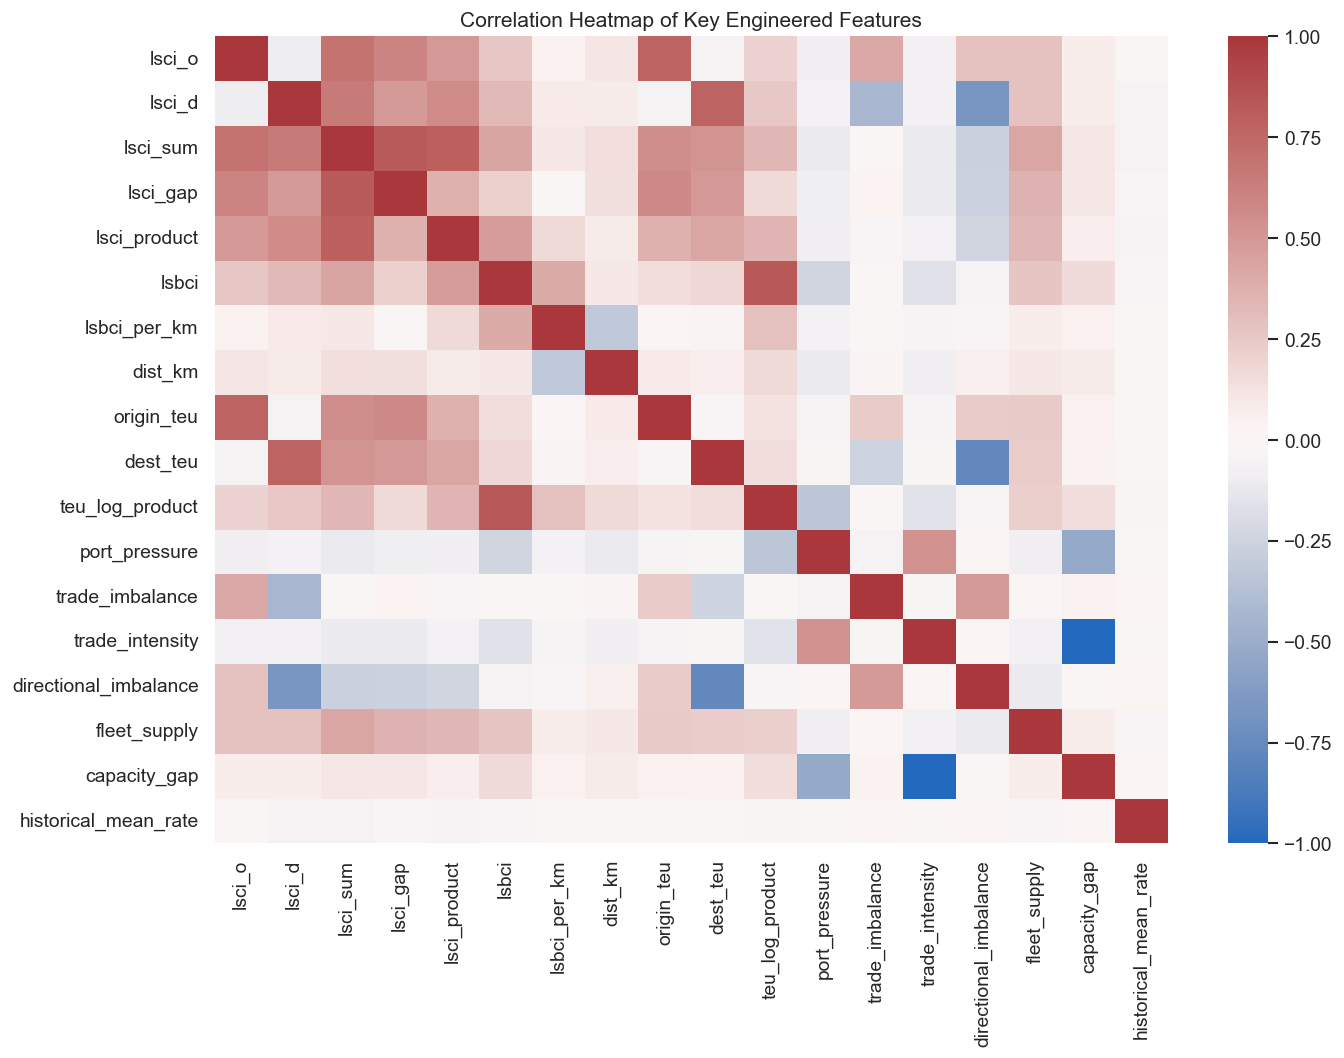

In [26]:
corr_features = [c for c in [
    "lsci_o", "lsci_d", "lsci_sum", "lsci_gap", "lsci_product",
    "lsbci", "lsbci_per_km", "dist_km",
    "origin_teu", "dest_teu", "teu_log_product", "port_pressure",
    "trade_imbalance", "trade_intensity", "directional_imbalance",
    "fleet_supply", "capacity_gap", "historical_mean_rate"
] if c in df_feat.columns]

corr_mat = df_feat[corr_features].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_mat, cmap="vlag", center=0)
plt.title("Correlation Heatmap of Key Engineered Features")
plt.tight_layout()
plt.show()


In [27]:
high_corr_pairs = []
for i, c1 in enumerate(corr_features):
    for c2 in corr_features[i+1:]:
        val = corr_mat.loc[c1, c2]
        if pd.notna(val) and abs(val) >= 0.85:
            high_corr_pairs.append((c1, c2, val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "corr"]).sort_values("corr", key=lambda s: s.abs(), ascending=False)
display(high_corr_df)


,feature_1,feature_2,corr
0,trade_intensity,capacity_gap,-1.0


## 12. Submission-ready auto-summary

This cell creates compact tables you can directly use while writing your report.


In [28]:
summary_table = missing_summary.rename(columns={"column": "feature"}).merge(
    corr_df[["feature", "pearson_r", "spearman_r", "n"]],
    on="feature",
    how="left"
).sort_values("spearman_r", key=lambda s: s.abs(), ascending=False)

display(summary_table.head(25))


,feature,missing_pct,pearson_r,spearman_r,n
8,historical_mean_rate,0.0,0.815905,0.854260,239499.0
18,dest_loaded_kt,0.0,-0.060460,-0.202650,239499.0
11,dest_vessel_pct,0.0,-0.047971,-0.200337,239499.0
17,dest_discharged_kt,0.0,-0.046982,-0.198396,239499.0
2,product_cat,0.0,-0.152514,-0.188341,239499.0
22,dest_teu,0.0,-0.037252,-0.147620,239499.0
1,lsci_d,0.0,-0.071802,-0.143808,239499.0
31,trade_imbalance,0.0,0.036801,0.127936,239499.0
10,fleet_supply,0.0,-0.033948,-0.106306,239499.0
13,directional_imbalance,0.0,0.028639,0.104474,239499.0


## Final EDA Key Findings

The exploratory data analysis shows that the freight-rate target is **strongly right-skewed**, with most observations concentrated at relatively low values and a small number of extreme high-rate outliers. This pattern is confirmed by both the histogram and boxplot, indicating that the raw target is not normally distributed and requires careful interpretation during modeling.

The year-wise analysis further shows that freight rates are **not stable over time**. Average freight rates generally decline toward 2019, followed by a recovery in 2020 and a stronger increase in 2021. This temporal pattern suggests that broader market conditions influence freight pricing and supports the inclusion of temporal controls such as `post_covid` and route-history features.

The feature validation results show that **`historical_mean_rate` is by far the strongest engineered predictor** of current freight rates. Both the correlation analysis and the binned plots show a strong positive and near-monotonic relationship, indicating substantial persistence in route-product pricing over time. This is economically intuitive, as freight costs on the same corridor tend to exhibit historical continuity.

**Connectivity-related features** also show meaningful relationships with freight rate. In particular, `lsbci`, `lsci_sum`, and `lsci_product` generally show inverse relationships with the target, suggesting that routes with stronger bilateral and endpoint shipping connectivity tend to have lower freight costs. This supports the use of maritime network variables to represent transport efficiency and route integration.

**Port-scale and supply-side features** are also informative. The binned relationship for `teu_log_product` suggests that larger origin–destination port systems are associated with lower freight rates, consistent with stronger logistics infrastructure and scale economies. Similarly, `fleet_supply` shows that greater vessel availability is generally associated with lower pricing pressure.

The EDA also indicates that **trade-balance features capture meaningful but more nonlinear effects**. Variables such as `trade_imbalance`, `directional_imbalance`, and `capacity_gap` help represent asymmetry in trade flows, route inefficiency, and supply-demand mismatch, although their standalone relationships with the target are weaker and less monotonic than those of the core history and connectivity features.

The product-wise analysis shows that **feature importance varies across commodity groups**, meaning that the relationship between predictors and freight rate is not identical for all products. This supports the inclusion of `product_cat` and suggests that freight pricing mechanisms differ by product type.

The imputation diagnostics show that **rows with imputed values often behave differently from fully observed rows**, particularly for TEU-related variables. This indicates that missingness is informative rather than purely random and justifies the inclusion of imputation flags in the final modeling table.

Finally, the redundancy analysis reveals that some engineered features carry overlapping information. In particular, `trade_intensity` and `capacity_gap` show near-deterministic overlap, while `lsci_gap` and `lsci_asymmetry` are also highly similar. These findings suggest that the engineered feature set is economically meaningful overall, but some variables should be interpreted as supporting proxies rather than fully independent signals.